# Cross-Site ESBL Prediction — Multi-Model External Validation

**7-model comparison** for cross-site AMR prediction with transfer learning analysis.

## Models
1. **LR** (L1 Logistic Regression) — interpretable baseline
2. **XGBoost** (Optuna 30-trial HPO) — gradient-boosted tree baseline
3. **FT-Transformer** (41K params) — feature tokenizer + transformer
4. **MHCA-VAE** (276K params) — multi-head cross-attention VAE with clinical group tokenization
5. **DA-VAE** (121K params) — domain-adaptive VAE with gradient reversal
6. **TabPFN v2.6** (43M params, frozen) — foundation model, in-context learning, zero training
7. **FTT-DANN** (42K params) — FT-Transformer + domain adversarial alignment

## Design
- True external validation: train on full Site A -> test on full Site B (natural prevalence)
- Bidirectional: MGB->Stanford AND Stanford->MGB  
- Transfer analysis: fine-tune source-trained models with 500-ALL target samples
- Patient-level splits, no data leakage

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import gc, time, warnings, json, copy
import pandas as pd
import numpy as np
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             brier_score_loss, roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    print(f"GPU: {torch.cuda.get_device_name(0)} | Free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB")

OUT_DIR = "cross_site_outputs_v10"
FIG_DIR = f"{OUT_DIR}/figures"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Device: {DEVICE}")


GPU: NVIDIA GeForce RTX 3090 | Free: 21.5 GB
Device: cuda:0


In [3]:
MGB_DIR      = "/data0/armd-mgb/physionet.org/files/armd-mgb/1.0.0"
STANFORD_DIR = "/data0/armd-stanford"

ENTERO_GENERA = ["ESCHERICHIA","KLEBSIELLA","ENTEROBACTER","PROTEUS",
    "CITROBACTER","SERRATIA","MORGANELLA","HAFNIA","PROVIDENCIA","CRONOBACTER"]
ESBL_ABX_CODES_MGB  = {"CRO","CAZ","FEP","TZP","cefsrc","cefpod","ceftaz","ceftrx","cefotx","cefoxn"}
ESBL_ABX_NAMES_STAN = ["ceftriaxone","ceftazidime","cefepime",
                        "piperacillin/tazobactam","piperacillin-tazobactam"]
AGE_MAP = {"18-24 years":1,"25-34 years":2,"35-44 years":3,"45-54 years":4,
    "55-64 years":5,"65-74 years":6,"75-84 years":7,"85-89 years":8,"above 90":9}
AGE_65PLUS = {"65-74 years","75-84 years","85-89 years","above 90"}
MGB_CLASS_MAP = {"T_fq_90d":["fluoroquinolone"],"T_ceph3_90d":["extended_spectrum_cephalosporin"],
    "T_carb_90d":["carbapenem"],"T_glyco_90d":["glycopeptide"],"T_sulfa_90d":["sulfonamide"],
    "T_esp_90d":["extended_spectrum_penicillin","beta_lactam_combo"],"T_amino_90d":["aminoglycoside"]}
STANFORD_SUBTYPE_MAP = {"T_fq_90d":["Fluoroquinolone"],
    "T_ceph3_90d":["Cephalosporin Gen3","Cephalosporin Gen4"],"T_carb_90d":["Carbapenem"],
    "T_glyco_90d":["Glycopeptide"],
    "T_sulfa_90d":["Sulfonamide","Sulfonamide Combo","Folate Synthesis Inhibitor"],
    "T_esp_90d":["Beta Lactam Combo"],"T_amino_90d":["Aminoglycoside"]}
ELIX_KEYWORDS = {
    "comorbid_heart_failure":["HEART FAILURE","CHF","CARDIAC FAILURE","CONGESTIVE HEART"],
    "comorbid_liver_disease":["LIVER","CIRRHOSIS","HEPATIC"],
    "comorbid_lymphoma":["LYMPHOMA","HODGKIN"],
    "comorbid_metastatic_cancer":["METASTATIC","SECONDARY MALIGNANCY"],
    "comorbid_obesity":["OBESITY"],
    "comorbid_renal_failure":["RENAL FAILURE","CHRONIC KIDNEY","CKD","ESRD"]}

_adi_tmp = pd.read_csv(f"{MGB_DIR}/ADI_deid_tj.csv", low_memory=False, usecols=["adi_score"])
_adi_tmp["adi_score"] = pd.to_numeric(_adi_tmp["adi_score"], errors="coerce")
ADI_HIGH_THRESHOLD = float(_adi_tmp["adi_score"].quantile(0.80))
del _adi_tmp

# Feature groups (for MHCA-VAE group tokenization)
FEATURE_DICT = {
    "demographics": ["age_encoded","gender_male","age_65plus","adi_score_clean","adi_missing","adi_high"],
    "comorbidities": ["comorbid_heart_failure","comorbid_liver_disease","comorbid_lymphoma",
        "comorbid_metastatic_cancer","comorbid_obesity","comorbid_renal_failure","elixhauser_count"],
    "ward": ["hosp_ward_IP","hosp_ward_OP","hosp_ward_ER"],
    "antibiotics": ["T_fq_90d","T_ceph3_90d","T_carb_90d","T_glyco_90d","T_sulfa_90d","T_esp_90d","T_amino_90d"],
    "resistance": ["prior_ESBL","num_prior_orgs","days_since_prior_org","prior_esbl_ast","prior_carb_resist","prior_n_resistant_abx"],
    "procedures": ["proc_cvc","proc_mechvent","proc_surgical","any_proc_30d"],
    "culture_organism": ["cx_urine","cx_blood","cx_resp","org_ecoli","org_klebsiella","org_entero","org_proteus","org_other"],
    "temporal_interactions": ["days_since_last_cx","has_prior_cx","fq_and_ceph3","any_immunocomp","any_invasive_proc","prior_esbl_and_ceph3","hospital_multiabx"],
}
FEATURES = [f for group in FEATURE_DICT.values() for f in group]
N_FEAT = len(FEATURES)
GROUP_SIZES = [len(g) for g in FEATURE_DICT.values()]
GROUP_INDICES = []
curr = 0
for size in GROUP_SIZES:
    GROUP_INDICES.append(list(range(curr, curr+size)))
    curr += size

assert N_FEAT == 48
print(f"Features: {N_FEAT} in {len(GROUP_SIZES)} groups: {GROUP_SIZES}")

Features: 48 in 8 groups: [6, 7, 3, 7, 6, 4, 8, 7]


## MGB Feature Engineering

In [4]:
t0 = time.time()
print("MGB Feature Engineering")

def safe_col(df, col, fill=0):
    return df[col].fillna(fill) if col in df.columns else pd.Series(fill, index=df.index)

micro = pd.read_csv(f"{MGB_DIR}/microbiology_cohort_deid_tj_updated.csv", low_memory=False)
pos_ast = micro[micro["organism"].notna() & (micro["has_AST"]=="X")].copy()
cb = (pos_ast.groupby("order_proc_id_coded")
      .agg(patient_id=("anon_id","first"), organism=("organism","first"),
           culture_description=("culture_description","first"),
           order_time=("order_time_jittered_utc_shifted","first")).reset_index())
cb = cb[cb["organism"].str.upper().apply(lambda x: any(g in str(x) for g in ENTERO_GENERA))]
cids = set(cb["order_proc_id_coded"])
esbl_ids = set(pos_ast[pos_ast["order_proc_id_coded"].isin(cids) &
    pos_ast["AST_code"].isin(ESBL_ABX_CODES_MGB) & (pos_ast["CLSI_2022_pheno"]=="Resistant")
]["order_proc_id_coded"])
del micro, pos_ast; gc.collect()

mgb = cb.copy()
mgb["ESBL"] = mgb["order_proc_id_coded"].isin(esbl_ids).astype(int)
mgb["order_dt"] = pd.to_datetime(mgb["order_time"], utc=True, errors="coerce")

# Demographics
demo = pd.read_csv(f"{MGB_DIR}/demographics_deid_tj.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
demo["age_encoded"] = demo["age"].map(AGE_MAP).fillna(0).astype(int)
demo["age_65plus"] = demo["age"].isin(AGE_65PLUS).astype(int)
demo["gender_male"] = (demo["gender"].astype(str).str.strip().str.lower()=="male").astype(int)
mgb = mgb.merge(demo[["order_proc_id_coded","age_encoded","age_65plus","gender_male"]], on="order_proc_id_coded", how="left")

# ADI
adi = pd.read_csv(f"{MGB_DIR}/ADI_deid_tj.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
adi["adi_score"] = pd.to_numeric(adi["adi_score"], errors="coerce")
adi["adi_score_clean"] = adi["adi_score"].fillna(0)
adi["adi_missing"] = adi["adi_score"].isna().astype(int)
adi["adi_high"] = (adi["adi_score"] > ADI_HIGH_THRESHOLD).fillna(False).astype(int)
mgb = mgb.merge(adi[["order_proc_id_coded","adi_score_clean","adi_missing","adi_high"]], on="order_proc_id_coded", how="left")

# Comorbidities
cmb = pd.read_csv(f"{MGB_DIR}/comorbidity_deid_tj.csv", low_memory=False)
cmb = cmb[cmb["order_proc_id_coded"].isin(cids)]
cu = cmb["category"].str.upper().fillna("")
for feat, kws in ELIX_KEYWORDS.items():
    mgb[feat] = mgb["order_proc_id_coded"].isin(
        set(cmb.loc[cu.apply(lambda x: any(k in x for k in kws)), "order_proc_id_coded"])).astype(int)
ec = cmb.groupby("order_proc_id_coded")["category"].nunique().reset_index().rename(columns={"category":"elixhauser_count"})
mgb = mgb.merge(ec, on="order_proc_id_coded", how="left")
del cmb; gc.collect()

# Ward
ward = pd.read_csv(f"{MGB_DIR}/ward_type_deid_tj.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
mgb = mgb.merge(ward[["order_proc_id_coded","hosp_ward_IP","hosp_ward_OP","hosp_ward_ER"]], on="order_proc_id_coded", how="left")

# Prior antibiotics (90-day window)
abx = pd.read_csv(f"{MGB_DIR}/prior_abx_deid_tj.csv", low_memory=False)
abx = abx[abx["order_proc_id_coded"].isin(cids)]
abx["days"] = pd.to_numeric(abx["last_dose_to_culture"], errors="coerce")
abx_90 = abx[(abx["days"]>0) & (abx["days"]<=90)]
dc_col = abx_90["drug_class"].str.lower().str.strip().fillna("")
for feat, classes in MGB_CLASS_MAP.items():
    mgb[feat] = mgb["order_proc_id_coded"].isin(
        set(abx_90.loc[dc_col.isin(classes), "order_proc_id_coded"])).astype(int)
del abx, abx_90; gc.collect()

# Prior organisms
po = pd.read_csv(f"{MGB_DIR}/prior_org_deid_tj.csv", low_memory=False)
po = po[po["order_proc_id_coded"].isin(cids)]
po["days"] = pd.to_numeric(po["prior_org_days_to_culture"], errors="coerce")
po = po[po["days"]>0]
spec = po["prior_org_specific"].str.upper().fillna("")
mgb["prior_ESBL"] = mgb["order_proc_id_coded"].isin(
    set(po.loc[spec.str.startswith("ESBL"), "order_proc_id_coded"])).astype(int)
npo = po.groupby("order_proc_id_coded")["prior_org"].nunique().reset_index().rename(columns={"prior_org":"num_prior_orgs"})
mgb = mgb.merge(npo, on="order_proc_id_coded", how="left")
dtbl = po.groupby("order_proc_id_coded")["days"].min().reset_index().rename(columns={"days":"days_since_prior_org"})
mgb = mgb.merge(dtbl, on="order_proc_id_coded", how="left")
del po; gc.collect()

# Procedures
proc = pd.read_csv(f"{MGB_DIR}/prior_procedures_deid_tj.csv", low_memory=False)
proc = proc[proc["order_proc_id_coded"].isin(cids)]
proc["days"] = pd.to_numeric(proc["procedure_days_culture"], errors="coerce")
proc = proc[proc["days"]>0]
pdesc = proc["procedure_description"].astype(str).str.strip().str.lower()
for p_name, p_key in [("proc_cvc","cvc"),("proc_mechvent","mechvent"),("proc_surgical","surgical_procedure")]:
    mgb[p_name] = mgb["order_proc_id_coded"].isin(set(proc.loc[pdesc==p_key,"order_proc_id_coded"])).astype(int)
mgb["any_proc_30d"] = ((mgb["proc_cvc"]+mgb["proc_mechvent"]+mgb["proc_surgical"])>0).astype(int)
del proc; gc.collect()

# Culture type
cx = mgb["culture_description"].str.upper().fillna("")
mgb["cx_urine"] = cx.str.contains("URINE",na=False).astype(int)
mgb["cx_blood"] = cx.str.contains("BLOOD",na=False).astype(int)
mgb["cx_resp"] = cx.str.contains("RESP",na=False).astype(int)

# Prior AST resistance (FIX: from actual AST data, not proxies)
ESBL_CODES = {"CRO","CAZ","FEP","TZP","ATM","CTX"}
CARB_CODES = {"MEM","IPM","ETP","DOR"}
pm = pd.read_csv(f"{MGB_DIR}/prior_micro_deid_tj.csv", low_memory=False)
pm["days"] = pd.to_numeric(pm["prior_AST_time_to_culture"], errors="coerce")
pm = pm[(pm["days"]>0) & (pm["days"]<=730) & pm["order_proc_id_coded"].isin(cids)]
is_res = pm["CLSI_2022_pheno"]=="Resistant"
mgb["prior_esbl_ast"] = mgb["order_proc_id_coded"].isin(
    set(pm.loc[is_res & pm["drug_code"].isin(ESBL_CODES), "order_proc_id_coded"])).astype(int)
mgb["prior_carb_resist"] = mgb["order_proc_id_coded"].isin(
    set(pm.loc[is_res & pm["drug_code"].isin(CARB_CODES), "order_proc_id_coded"])).astype(int)
prc = pm[is_res].groupby("order_proc_id_coded")["drug_code"].nunique().reset_index()
prc.columns = ["order_proc_id_coded","prior_n_resistant_abx"]
mgb = mgb.merge(prc, on="order_proc_id_coded", how="left")
mgb["prior_n_resistant_abx"] = mgb["prior_n_resistant_abx"].fillna(0).astype(int)
del pm, prc; gc.collect()

# Organism genus
org = mgb["organism"].str.upper().fillna("")
mgb["org_ecoli"] = org.str.contains("ESCHERICHIA",na=False).astype(int)
mgb["org_klebsiella"] = org.str.contains("KLEBSIELLA",na=False).astype(int)
mgb["org_entero"] = org.str.contains("ENTEROBACTER",na=False).astype(int)
mgb["org_proteus"] = org.str.contains("PROTEUS",na=False).astype(int)
mgb["org_other"] = ((~org.str.contains("ESCHERICHIA|KLEBSIELLA|ENTEROBACTER|PROTEUS",na=False)) &
                     org.apply(lambda x: any(g in x for g in ENTERO_GENERA))).astype(int)

# FIX: days_since_last_cx — sort in place, no .values
mgb = mgb.sort_values(["patient_id","order_dt"]).reset_index(drop=True)
mgb["days_since_last_cx"] = mgb.groupby("patient_id")["order_dt"].diff().dt.total_seconds().div(86400).fillna(0).clip(0,3650)
mgb["has_prior_cx"] = (mgb["days_since_last_cx"]>0).astype(int)

# Derived features
mgb["fq_and_ceph3"] = ((mgb["T_fq_90d"]>0) & (mgb["T_ceph3_90d"]>0)).astype(int)
mgb["any_immunocomp"] = ((mgb["comorbid_lymphoma"]>0) | (mgb["comorbid_metastatic_cancer"]>0)).astype(int)
mgb["any_invasive_proc"] = ((mgb["proc_cvc"]>0) | (mgb["proc_mechvent"]>0)).astype(int)
mgb["prior_esbl_and_ceph3"] = ((mgb["prior_ESBL"]>0) & (mgb["T_ceph3_90d"]>0)).astype(int)
mgb["hospital_multiabx"] = ((mgb["hosp_ward_IP"]>0) &
    (mgb[["T_fq_90d","T_ceph3_90d","T_carb_90d","T_glyco_90d","T_sulfa_90d","T_esp_90d","T_amino_90d"]].sum(axis=1)>=2)).astype(int)

# Fill NAs and finalize
id_set = {"order_proc_id_coded","organism","culture_description","order_time","order_dt","patient_id","site","ESBL"}
for col in mgb.columns:
    if col not in id_set: mgb[col] = mgb[col].fillna(0)
mgb["site"] = "MGB"
for f in FEATURES:
    if f not in mgb.columns: mgb[f] = 0

assert mgb["order_proc_id_coded"].duplicated().sum() == 0
assert all(f in mgb.columns for f in FEATURES)
print(f"  MGB: {len(mgb):,} cultures | ESBL+ {mgb['ESBL'].sum():,} ({mgb['ESBL'].mean():.2%}) | {time.time()-t0:.0f}s")

MGB Feature Engineering
  MGB: 133,084 cultures | ESBL+ 19,223 (14.44%) | 70s


## Stanford Feature Engineering

In [5]:
t0 = time.time()
print("Stanford Feature Engineering")

cul = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_cohort.csv", low_memory=False)
cul["order_dt"] = pd.to_datetime(cul["order_time_jittered_utc"], utc=True, errors="coerce")
org_upper = cul["organism"].str.upper().fillna("")
abx_lower = cul["antibiotic"].str.lower().fillna("")
susc = cul["susceptibility"].str.strip().fillna("")
is_entero = org_upper.apply(lambda x: any(g in x for g in ENTERO_GENERA))
is_esbl_abx = abx_lower.apply(lambda x: any(a in x for a in ESBL_ABX_NAMES_STAN))
esbl_cids = set(cul.loc[is_entero & is_esbl_abx & (susc=="Resistant"), "order_proc_id_coded"])
stan = (cul[is_entero].drop_duplicates("order_proc_id_coded")
        [["order_proc_id_coded","anon_id","order_dt","organism","culture_description"]].copy())
stan.rename(columns={"anon_id":"patient_id"}, inplace=True)
stan["ESBL"] = stan["order_proc_id_coded"].isin(esbl_cids).astype(int)
sids = set(stan["order_proc_id_coded"])

# FIX: prior_ESBL — per-patient shift via transform (not global shift)
flags = (cul[is_entero].drop_duplicates("order_proc_id_coded")
         [["order_proc_id_coded","anon_id","order_dt"]].copy())
flags["flag_ESBL"] = flags["order_proc_id_coded"].isin(esbl_cids).astype(int)
flags = flags.sort_values(["anon_id","order_dt"])
flags["prior_ESBL"] = flags.groupby("anon_id")["flag_ESBL"].transform(lambda x: x.cummax().shift(1)).fillna(0).astype(int)
flags["num_prior_orgs"] = flags.groupby("anon_id").cumcount()
flags["days_since_prior_org"] = (flags["order_dt"] - flags.groupby("anon_id")["order_dt"].shift(1)).dt.total_seconds().div(86400).fillna(0)
stan = stan.merge(flags[["order_proc_id_coded","prior_ESBL","num_prior_orgs","days_since_prior_org"]],
                  on="order_proc_id_coded", how="left")
del flags, cul; gc.collect()

# Demographics
dem = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_demographics.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
dem["age_encoded"] = dem["age"].map(AGE_MAP).fillna(0).astype(int)
dem["age_65plus"] = dem["age"].isin(AGE_65PLUS).astype(int)
dem["gender"] = pd.to_numeric(dem["gender"].replace("Null",np.nan), errors="coerce")
dem["gender_male"] = (dem["gender"]==1).astype(int)
stan = stan.merge(dem[["order_proc_id_coded","age_encoded","age_65plus","gender_male"]], on="order_proc_id_coded", how="left")
# Sanity check
gmr = stan["gender_male"].mean()
assert 0.1 < gmr < 0.9, f"gender_male={gmr:.2%} — likely mismapped"
del dem; gc.collect()

# ADI
adi = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_adi_scores.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
adi["adi_score"] = pd.to_numeric(adi["adi_score"], errors="coerce")
adi["adi_score_clean"] = adi["adi_score"].fillna(0)
adi["adi_missing"] = adi["adi_score"].isna().astype(int)
adi["adi_high"] = (adi["adi_score"] > ADI_HIGH_THRESHOLD).fillna(False).astype(int)
stan = stan.merge(adi[["order_proc_id_coded","adi_score_clean","adi_missing","adi_high"]], on="order_proc_id_coded", how="left")
del adi; gc.collect()

# Ward
ward = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_ward_info.csv", low_memory=False).drop_duplicates("order_proc_id_coded")
stan = stan.merge(ward[["order_proc_id_coded","hosp_ward_IP","hosp_ward_OP","hosp_ward_ER"]], on="order_proc_id_coded", how="left")
del ward; gc.collect()

# Comorbidities (from cache)
CACHE = "cross_site_outputs_v5/stan_cmb_cache.parquet"
cmb_feats = pd.read_parquet(CACHE)
stan = stan.merge(cmb_feats, on="order_proc_id_coded", how="left")
del cmb_feats; gc.collect()

# Prior antibiotics
abx = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_antibiotic_subtype_exposure.csv", low_memory=False)
abx = abx[abx["order_proc_id_coded"].isin(sids)]
abx["days"] = pd.to_numeric(abx["medication_time_to_cultureTime"].replace("Null",np.nan), errors="coerce")
abx_90 = abx[(abx["days"]>0) & (abx["days"]<=90)]
subtype = abx_90["antibiotic_subtype"].str.strip().fillna("")
for feat, subtypes in STANFORD_SUBTYPE_MAP.items():
    stan[feat] = stan["order_proc_id_coded"].isin(
        set(abx_90.loc[subtype.isin(subtypes), "order_proc_id_coded"])).astype(int)
del abx, abx_90; gc.collect()

# Procedures
proc = pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_priorprocedures.csv", low_memory=False)
proc = proc[proc["order_proc_id_coded"].isin(sids)]
proc["days"] = pd.to_numeric(proc["procedure_time_to_culturetime"].replace("Null",np.nan), errors="coerce")
proc = proc[proc["days"]>0]
pdesc = proc["procedure_description"].astype(str).str.strip().str.lower()
for p_name, p_key in [("proc_cvc","cvc"),("proc_mechvent","mechvent"),("proc_surgical","surgical_procedure")]:
    stan[p_name] = stan["order_proc_id_coded"].isin(set(proc.loc[pdesc==p_key,"order_proc_id_coded"])).astype(int)
stan["any_proc_30d"] = ((stan["proc_cvc"]+stan["proc_mechvent"]+stan["proc_surgical"])>0).astype(int)
del proc; gc.collect()

# Culture type
cx = stan["culture_description"].str.upper().fillna("")
stan["cx_urine"] = cx.str.contains("URINE",na=False).astype(int)
stan["cx_blood"] = cx.str.contains("BLOOD",na=False).astype(int)
stan["cx_resp"] = cx.str.contains("RESP",na=False).astype(int)

# FIX: Prior AST resistance — collect ALL Enterobacteriaceae resistance (not just ESBL antibiotics)
ESBL_ABX_MR = {"ceftriaxone","ceftazidime","cefepime","cefoxitin","aztreonam","cefotaxime"}
CARB_ABX_MR = {"meropenem","imipenem","ertapenem","doripenem"}
print("  Scanning microbial_resistance.csv...")
entero_rows = []
for chunk in pd.read_csv(f"{STANFORD_DIR}/microbiology_cultures_microbial_resistance.csv",
                         low_memory=False, chunksize=500_000):
    chunk["days"] = pd.to_numeric(chunk["resistant_time_to_culturetime"].replace("Null",np.nan), errors="coerce")
    chunk = chunk[(chunk["days"]>0) & chunk["order_proc_id_coded"].isin(sids)]
    org_up = chunk["organism"].str.upper().fillna("")
    is_ent = org_up.apply(lambda x: any(g in x for g in ENTERO_GENERA))
    if is_ent.any():
        entero_rows.append(chunk[is_ent].copy())

if entero_rows:
    mr_ent = pd.concat(entero_rows, ignore_index=True)
    abx_lower_mr = mr_ent["antibiotic"].str.lower().fillna("")
    stan["prior_esbl_ast"] = stan["order_proc_id_coded"].isin(
        set(mr_ent.loc[abx_lower_mr.isin(ESBL_ABX_MR), "order_proc_id_coded"])).astype(int)
    stan["prior_carb_resist"] = stan["order_proc_id_coded"].isin(
        set(mr_ent.loc[abx_lower_mr.isin(CARB_ABX_MR), "order_proc_id_coded"])).astype(int)
    prc_stan = mr_ent.groupby("order_proc_id_coded")["antibiotic"].nunique().reset_index()
    prc_stan.columns = ["order_proc_id_coded","prior_n_resistant_abx"]
    stan = stan.merge(prc_stan, on="order_proc_id_coded", how="left")
    stan["prior_n_resistant_abx"] = stan["prior_n_resistant_abx"].fillna(0).astype(int)
    print(f"    prior_esbl_ast: {stan['prior_esbl_ast'].sum():,} | prior_carb_resist: {stan['prior_carb_resist'].sum():,}")
    del mr_ent, entero_rows, prc_stan; gc.collect()
else:
    for f in ["prior_esbl_ast","prior_carb_resist","prior_n_resistant_abx"]: stan[f] = 0

# Organism genus
org = stan["organism"].str.upper().fillna("")
stan["org_ecoli"] = org.str.contains("ESCHERICHIA",na=False).astype(int)
stan["org_klebsiella"] = org.str.contains("KLEBSIELLA",na=False).astype(int)
stan["org_entero"] = org.str.contains("ENTEROBACTER",na=False).astype(int)
stan["org_proteus"] = org.str.contains("PROTEUS",na=False).astype(int)
stan["org_other"] = ((~org.str.contains("ESCHERICHIA|KLEBSIELLA|ENTEROBACTER|PROTEUS",na=False)) &
                      org.apply(lambda x: any(g in x for g in ENTERO_GENERA))).astype(int)

# FIX: days_since_last_cx — index-safe
stan = stan.sort_values(["patient_id","order_dt"]).reset_index(drop=True)
stan["days_since_last_cx"] = stan.groupby("patient_id")["order_dt"].diff().dt.total_seconds().div(86400).fillna(0).clip(0,3650)
stan["has_prior_cx"] = (stan["days_since_last_cx"]>0).astype(int)

# Derived
stan["fq_and_ceph3"] = ((stan["T_fq_90d"]>0) & (stan["T_ceph3_90d"]>0)).astype(int)
stan["any_immunocomp"] = ((stan["comorbid_lymphoma"]>0) | (stan["comorbid_metastatic_cancer"]>0)).astype(int)
stan["any_invasive_proc"] = ((stan["proc_cvc"]>0) | (stan["proc_mechvent"]>0)).astype(int)
stan["prior_esbl_and_ceph3"] = ((stan["prior_ESBL"]>0) & (stan["T_ceph3_90d"]>0)).astype(int)
stan["hospital_multiabx"] = ((stan["hosp_ward_IP"]>0) &
    (stan[["T_fq_90d","T_ceph3_90d","T_carb_90d","T_glyco_90d","T_sulfa_90d","T_esp_90d","T_amino_90d"]].sum(axis=1)>=2)).astype(int)

id_set = {"order_proc_id_coded","organism","culture_description","order_dt","patient_id","site","ESBL"}
for col in stan.columns:
    if col not in id_set: stan[col] = stan[col].fillna(0)
stan["site"] = "Stanford"
for f in FEATURES:
    if f not in stan.columns: stan[f] = 0

assert stan["order_proc_id_coded"].duplicated().sum() == 0
assert all(f in stan.columns for f in FEATURES)
print(f"  Stanford: {len(stan):,} cultures | ESBL+ {stan['ESBL'].sum():,} ({stan['ESBL'].mean():.2%}) | {time.time()-t0:.0f}s")

Stanford Feature Engineering
  Scanning microbial_resistance.csv...
    prior_esbl_ast: 9,910 | prior_carb_resist: 427
  Stanford: 83,373 cultures | ESBL+ 8,698 (10.43%) | 26s


## Model Architectures

Seven models compared:
1. **LR** (L1 Logistic Regression) — interpretable baseline
2. **XGBoost** (Optuna 30-trial HPO) — gradient-boosted tree baseline
3. **FT-Transformer** (41K params) — feature tokenizer + transformer
4. **MHCA-VAE** (276K params) — multi-head cross-attention VAE with clinical group tokenization
5. **DA-VAE** (121K params) — domain-adaptive VAE with gradient reversal
6. **TabPFN v2.6** (43M params, frozen) — foundation model, in-context learning
7. **FTT-DANN** (42K params) — FT-Transformer + domain adversarial alignment


In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__(); self.alpha=alpha; self.gamma=gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = targets*torch.sigmoid(logits)+(1-targets)*(1-torch.sigmoid(logits))
        at = targets*self.alpha+(1-targets)*(1-self.alpha)
        return (at*(1-pt)**self.gamma*bce).mean()

class GroupTokenizer(nn.Module):
    def __init__(self, group_sizes, d_token):
        super().__init__()
        self.projections = nn.ModuleList([
            nn.Sequential(nn.Linear(gs, d_token), nn.LayerNorm(d_token), nn.GELU()) for gs in group_sizes])
    def forward(self, groups):
        return torch.stack([proj(g) for proj, g in zip(self.projections, groups)], dim=1)

class MultiHeadCrossAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads; self.d_k = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model); self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model); self.W_o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        B, N, D = x.shape
        q = self.W_q(x).view(B, N, self.n_heads, self.d_k).transpose(1,2)
        k = self.W_k(x).view(B, N, self.n_heads, self.d_k).transpose(1,2)
        v = self.W_v(x).view(B, N, self.n_heads, self.d_k).transpose(1,2)
        attn = self.drop(F.softmax((q @ k.transpose(-2,-1)) / (self.d_k**0.5), dim=-1))
        out = (attn @ v).transpose(1,2).reshape(B,N,D)
        return self.W_o(out), attn

class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model); self.attn = MultiHeadCrossAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
                                nn.Linear(d_ff, d_model), nn.Dropout(dropout))
    def forward(self, x):
        h, attn_w = self.attn(self.ln1(x))
        x = x + h; x = x + self.ff(self.ln2(x))
        return x, attn_w

class MHCAVAE(nn.Module):
    def __init__(self, group_sizes, d_token=64, n_heads=4, n_layers=3, d_ff=256,
                 latent_dim=64, dropout=0.15, n_features_total=48):
        super().__init__()
        self.n_features = n_features_total; self.n_groups = len(group_sizes)
        self.tokenizer = GroupTokenizer(group_sizes, d_token)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_token)*0.02)
        self.layers = nn.ModuleList([CrossAttentionBlock(d_token, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_token)
        self.fc_mu = nn.Linear(d_token, latent_dim); self.fc_logvar = nn.Linear(d_token, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256,256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, n_features_total))
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim,128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128,64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64,1))
    def split_groups(self, x, group_indices): return [x[:, idx] for idx in group_indices]
    def encode(self, x, group_indices):
        groups = self.split_groups(x, group_indices)
        tokens = self.tokenizer(groups)
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        attn_weights = []
        for layer in self.layers:
            tokens, aw = layer(tokens); attn_weights.append(aw)
        cls_out = self.ln(tokens[:,0])
        return self.fc_mu(cls_out), self.fc_logvar(cls_out), attn_weights
    def reparameterize(self, mu, logvar):
        if self.training: return mu + torch.randn_like(mu) * torch.exp(0.5*logvar)
        return mu
    def forward(self, x, group_indices):
        mu, logvar, attn_weights = self.encode(x, group_indices)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), self.classifier(z).squeeze(-1), mu, logvar, z, attn_weights
    def predict(self, x, group_indices):
        mu, _, _ = self.encode(x, group_indices)
        return torch.sigmoid(self.classifier(mu).squeeze(-1))

class FeatureTokenizer(nn.Module):
    def __init__(self, n_features, d_token):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_token)*0.02)
        self.bias = nn.Parameter(torch.zeros(n_features, d_token))
    def forward(self, x): return x.unsqueeze(-1)*self.weight.unsqueeze(0)+self.bias.unsqueeze(0)

class MHA(nn.Module):
    def __init__(self, d, n_heads, drop=0.1):
        super().__init__()
        self.n_heads=n_heads; self.d_k=d//n_heads
        self.W_q=nn.Linear(d,d); self.W_k=nn.Linear(d,d); self.W_v=nn.Linear(d,d); self.W_o=nn.Linear(d,d)
        self.drop=nn.Dropout(drop)
    def forward(self, x):
        B,N,D=x.shape
        q=self.W_q(x).view(B,N,self.n_heads,self.d_k).transpose(1,2)
        k=self.W_k(x).view(B,N,self.n_heads,self.d_k).transpose(1,2)
        v=self.W_v(x).view(B,N,self.n_heads,self.d_k).transpose(1,2)
        attn=self.drop(F.softmax((q@k.transpose(-2,-1))/(self.d_k**0.5),dim=-1))
        return self.W_o((attn@v).transpose(1,2).reshape(B,N,D))

class TBlock(nn.Module):
    def __init__(self, d, n_heads, d_ff, drop=0.1):
        super().__init__()
        self.ln1=nn.LayerNorm(d); self.attn=MHA(d,n_heads,drop); self.ln2=nn.LayerNorm(d)
        self.ff=nn.Sequential(nn.Linear(d,d_ff),nn.GELU(),nn.Dropout(drop),nn.Linear(d_ff,d),nn.Dropout(drop))
    def forward(self, x): x=x+self.attn(self.ln1(x)); x=x+self.ff(self.ln2(x)); return x

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, d_ff=128, dropout=0.2):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_token)*0.02)
        self.layers = nn.ModuleList([TBlock(d_token, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_token); self.head = nn.Linear(d_token, 1)
    def forward(self, x):
        tokens = torch.cat([self.cls_token.expand(x.shape[0],-1,-1), self.tokenizer(x)], dim=1)
        for layer in self.layers: tokens = layer(tokens)
        return self.head(self.ln(tokens[:,0])).squeeze(-1)

print(f"MHCA-VAE params: {sum(p.numel() for p in MHCAVAE(GROUP_SIZES, n_features_total=N_FEAT).parameters()):,}")
print(f"FTT params:      {sum(p.numel() for p in FTTransformer(N_FEAT).parameters()):,}")

# ── DA-VAE (Domain-Adaptive VAE from v7/v9) ──
class GradRevFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha): ctx.alpha = alpha; return x.view_as(x)
    @staticmethod
    def backward(ctx, grad): return grad.neg()*ctx.alpha, None

class GRL(nn.Module):
    def __init__(self): super().__init__(); self.alpha = 1.0
    def forward(self, x): return GradRevFn.apply(x, self.alpha)

class DAVAEEncoder(nn.Module):
    def __init__(self, n_feat, hidden, latent):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_feat, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden//2), nn.LayerNorm(hidden//2), nn.GELU(), nn.Dropout(0.1))
        self.mu = nn.Linear(hidden//2, latent)
        self.log_var = nn.Linear(hidden//2, latent)
    def forward(self, x):
        h = self.net(x); return self.mu(h), self.log_var(h)

class DAVAEDecoder(nn.Module):
    def __init__(self, latent, hidden, n_feat):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent, hidden//2), nn.LayerNorm(hidden//2), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden//2, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(hidden, n_feat))
    def forward(self, z): return self.net(z)

class DomainAdaptiveVAE(nn.Module):
    def __init__(self, n_feat, hidden=256, latent=64):
        super().__init__()
        self.encoder = DAVAEEncoder(n_feat, hidden, latent)
        self.decoder = DAVAEDecoder(latent, hidden, n_feat)
        self.classifier = nn.Sequential(
            nn.Linear(latent, latent//2), nn.GELU(), nn.Dropout(0.1), nn.Linear(latent//2, 1))
        self.grl = GRL()
        self.domain = nn.Sequential(
            nn.Linear(latent, latent//2), nn.GELU(), nn.Dropout(0.1), nn.Linear(latent//2, 1))
    def reparameterize(self, mu, lv):
        if self.training: return mu + torch.randn_like(mu) * torch.exp(0.5*lv)
        return mu
    def forward(self, x, alpha=1.0):
        mu, lv = self.encoder(x); z = self.reparameterize(mu, lv)
        self.grl.alpha = alpha
        return (self.decoder(z), self.classifier(z).squeeze(-1),
                self.domain(self.grl(z)).squeeze(-1), mu, lv, z)
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            mu, lv = self.encoder(x); z = self.reparameterize(mu, lv)
            return torch.sigmoid(self.classifier(z).squeeze(-1))

print(f"DA-VAE params:   {sum(p.numel() for p in DomainAdaptiveVAE(N_FEAT).parameters()):,}")


MHCA-VAE params: 275,889
FTT params:      41,313
DA-VAE params:   121,394


## Training and Evaluation Utilities


In [7]:
def train_mhcavae(model, trl, vll, group_indices, epochs=150, lr=5e-4, pat=20):
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    focal = FocalLoss(0.25, 2.0)
    gi = [torch.tensor(g) for g in group_indices]
    best, bst, noi = 0, None, 0
    for ep in range(epochs):
        model.train()
        for X, y in trl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            x_recon, y_logit, mu, logvar, z, _ = model(X, gi)
            recon = F.mse_loss(x_recon, X)
            kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            cls = focal(y_logit, y)
            loss = recon + 0.01*kl + 5.0*cls
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
        model.eval()
        vp, vy = [], []
        with torch.no_grad():
            for Xv, yv in vll:
                vp.append(model.predict(Xv.to(DEVICE), gi).cpu().numpy()); vy.append(yv.numpy())
        auroc = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        if auroc > best: best=auroc; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; noi=0
        else: noi+=1
        if ep % 30 == 0: print(f"    ep {ep:3d} | val_auroc={auroc:.4f} best={best:.4f}")
        if noi>=pat: print(f"    Early stop ep {ep}"); break
    if bst: model.load_state_dict(bst); model.to(DEVICE)
    return model

def train_ftt(model, trl, vll, epochs=150, lr=5e-4, pat=20):
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, epochs=epochs, steps_per_epoch=len(trl), pct_start=0.1)
    focal = FocalLoss(0.25, 2.0)
    best, bst, noi = 0, None, 0
    for ep in range(epochs):
        model.train()
        for X, y in trl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); focal(model(X), y).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); sched.step()
        model.eval()
        vp, vy = [], []
        with torch.no_grad():
            for Xv, yv in vll:
                vp.append(torch.sigmoid(model(Xv.to(DEVICE))).cpu().numpy()); vy.append(yv.numpy())
        auroc = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        if auroc > best: best=auroc; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; noi=0
        else: noi+=1
        if noi>=pat: print(f"    FTT early stop ep {ep}"); break
    if bst: model.load_state_dict(bst); model.to(DEVICE)
    return model

def pred_ftt(model, X, bs=1024):
    model.eval(); dl = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=bs)
    ps = []
    with torch.no_grad():
        for (b,) in dl: ps.append(torch.sigmoid(model(b.to(DEVICE))).cpu().numpy())
    return np.concatenate(ps)

def pred_mhcavae(model, X, group_indices, bs=1024):
    model.eval(); gi = [torch.tensor(g) for g in group_indices]
    dl = DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32)), batch_size=bs)
    ps = []
    with torch.no_grad():
        for (b,) in dl: ps.append(model.predict(b.to(DEVICE), gi).cpu().numpy())
    return np.concatenate(ps)

def balance_cohort(X, y, seed=SEED):
    pos_idx = np.where(y == 1)[0]; neg_idx = np.where(y == 0)[0]
    rng = np.random.RandomState(seed)
    neg_sampled = rng.choice(neg_idx, size=len(pos_idx), replace=False)
    bal_idx = np.concatenate([pos_idx, neg_sampled]); rng.shuffle(bal_idx)
    return X[bal_idx], y[bal_idx]

def eval_ci(y, p, label, nb=2000):
    auroc = roc_auc_score(y,p); auprc = average_precision_score(y,p); brier = brier_score_loss(y,p)
    rng = np.random.RandomState(SEED); ba = []
    for _ in range(nb):
        i = rng.choice(len(y), len(y), replace=True)
        if y[i].sum()<5 or y[i].sum()==len(i): continue
        ba.append(roc_auc_score(y[i], p[i]))
    ci = (np.percentile(ba,2.5), np.percentile(ba,97.5))
    print(f"  {label:<48s} AUROC={auroc:.4f} [{ci[0]:.4f}-{ci[1]:.4f}] AUPRC={auprc:.4f} Brier={brier:.4f}")
    return {"auroc":auroc,"auprc":auprc,"brier":brier,"ci":ci,"p":p}

def calculate_dca(y_true, y_prob, thresholds):
    net_benefits = []; N = len(y_true)
    for t in thresholds:
        tp = np.sum((y_prob >= t) & (y_true == 1)); fp = np.sum((y_prob >= t) & (y_true == 0))
        if t >= 1.0: t = 0.9999
        net_benefits.append((tp/N) - (fp/N)*(t/(1-t)))
    return np.array(net_benefits)

def generate_4panel_plot(y_test, models, direction_title, save_path):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    ax = axes[0,0]
    for name, (probs, color, ls) in models.items():
        fpr, tpr, _ = roc_curve(y_test, probs)
        ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2.5, label=f"{name} ({roc_auc_score(y_test, probs):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title("A. ROC Curve", fontweight="bold", fontsize=14)
    ax.set_xlabel("1 - Specificity"); ax.set_ylabel("Sensitivity"); ax.legend(loc="lower right")
    ax = axes[0,1]
    for name, (probs, color, ls) in models.items():
        prec, rec, _ = precision_recall_curve(y_test, probs)
        ax.plot(rec, prec, color=color, linestyle=ls, lw=2.5, label=f"{name} ({average_precision_score(y_test, probs):.3f})")
    ax.axhline(y_test.mean(), color="k", linestyle="--", lw=1, label=f"Prevalence ({y_test.mean():.3f})")
    ax.set_title("B. Precision-Recall Curve", fontweight="bold", fontsize=14)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(loc="upper right")
    ax = axes[1,0]
    for name, (probs, color, ls) in models.items():
        prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
        ax.plot(prob_pred, prob_true, "s-", color=color, label=f"{name} (Brier={brier_score_loss(y_test,probs):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title("C. Calibration", fontweight="bold", fontsize=14)
    ax.set_xlabel("Predicted Probability"); ax.set_ylabel("Observed Proportion"); ax.legend(loc="upper left")
    ax = axes[1,1]
    thresholds = np.linspace(0.01, 0.40, 50)
    for name, (probs, color, ls) in models.items():
        ax.plot(thresholds, calculate_dca(y_test, probs, thresholds), color=color, linestyle=ls, lw=2.5, label=name)
    treat_all = y_test.mean() - (1-y_test.mean())*(thresholds/(1-thresholds))
    ax.plot(thresholds, treat_all, "k:", lw=2, label="Treat All"); ax.axhline(0, color="k", lw=2, label="Treat None")
    ax.set_ylim(-0.02, 0.12); ax.set_title("D. Decision Curve Analysis", fontweight="bold", fontsize=14)
    ax.set_xlabel("Threshold Probability"); ax.set_ylabel("Net Benefit"); ax.legend(loc="upper right")
    plt.suptitle(direction_title, fontsize=16, fontweight="bold"); plt.tight_layout()
    plt.savefig(save_path, dpi=300); plt.close()
    print(f"  Saved: {save_path}")



def pred_davae(model, X, bs=1024):
    model.eval(); ps = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            ps.append(model.predict(torch.FloatTensor(X[i:i+bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(ps)

def train_davae_single(X_tr, y_tr, X_val, y_val, epochs=100, patience=15, lr=5e-4):
    """Train DA-VAE on single site (recon + KL + classifier, no domain loss)."""
    torch.cuda.empty_cache(); gc.collect()
    model = DomainAdaptiveVAE(N_FEAT).to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
    pw = torch.tensor([cw[1]/cw[0]]).to(DEVICE)
    tc = nn.BCEWithLogitsLoss(pos_weight=pw)
    sw = np.where(y_tr==1, cw[1], cw[0])
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
                        batch_size=256, sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
    best, bst, pat = 0.0, None, 0
    for ep in range(1, epochs+1):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE); opt.zero_grad()
            xh, yl, _, mu, lv, _ = model(bx)
            recon = F.mse_loss(xh, bx)
            kl = -0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())
            loss = recon + 0.01*kl + 2.0*tc(yl, by)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        va = roc_auc_score(y_val, pred_davae(model, X_val))
        if va > best: best=va; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; pat=0
        else: pat+=1
        if ep % 30 == 0: print(f"    DA-VAE ep {ep:3d} | val_auroc={va:.4f} best={best:.4f}")
        if pat>=patience: print(f"    DA-VAE early stop ep {ep}"); break
    model.load_state_dict(bst)
    return model, bst

def fine_tune_davae(state, X_tr, y_tr, X_val, y_val, epochs=60, patience=10, lr=1e-4):
    """Fine-tune DA-VAE from pre-trained state."""
    torch.cuda.empty_cache(); gc.collect()
    model = DomainAdaptiveVAE(N_FEAT).to(DEVICE); model.load_state_dict(state)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
    pw = torch.tensor([cw[1]/cw[0]]).to(DEVICE)
    tc = nn.BCEWithLogitsLoss(pos_weight=pw)
    sw = np.where(y_tr==1, cw[1], cw[0])
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
                        batch_size=min(256, max(len(X_tr)//4, 16)),
                        sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
    best, bst, pat = 0.0, None, 0
    for ep in range(1, epochs+1):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE); opt.zero_grad()
            xh, yl, _, mu, lv, _ = model(bx)
            loss = F.mse_loss(xh, bx) + 0.01*(-0.5*torch.mean(1+lv-mu.pow(2)-lv.exp())) + 2.0*tc(yl, by)
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        va = roc_auc_score(y_val, pred_davae(model, X_val))
        if va > best: best=va; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; pat=0
        else: pat+=1
        if pat>=patience: break
    model.load_state_dict(bst)
    return model

def train_ftt_from_state(state, trl, vll, epochs=60, lr=1e-4, pat=10):
    """Fine-tune FTT from saved state."""
    model = FTTransformer(N_FEAT, d_token=32, n_heads=4, n_layers=3, d_ff=128, dropout=0.2).to(DEVICE)
    model.load_state_dict(state)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    focal = FocalLoss(0.25, 2.0)
    best, bst, noi = 0, None, 0
    for ep in range(epochs):
        model.train()
        for X, y in trl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(); focal(model(X), y).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        model.eval()
        vp, vy = [], []
        with torch.no_grad():
            for Xv, yv in vll:
                vp.append(torch.sigmoid(model(Xv.to(DEVICE))).cpu().numpy()); vy.append(yv.numpy())
        auroc = roc_auc_score(np.concatenate(vy), np.concatenate(vp))
        if auroc > best: best=auroc; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; noi=0
        else: noi+=1
        if noi>=pat: break
    if bst: model.load_state_dict(bst); model.to(DEVICE)
    return model


## Experiment Runner

For each direction:
1. Scaler fit on **training site only** — no target data leakage
2. Patient-level validation split within training site (GroupShuffleSplit)
3. LR/XGB: trained on balanced cohort; FTT/MHCA-VAE/DA-VAE: WeightedRandomSampler
4. Isotonic calibration for MHCA-VAE and DA-VAE on validation set
5. Evaluate on **full test site at natural prevalence**


In [8]:
def run_experiment(train_df, test_df, train_name, test_name):
    print(f"\n{'='*70}")
    print(f"EXPERIMENT: {train_name} -> {test_name}")
    print(f"  Train: {len(train_df):,} ({train_df['ESBL'].mean():.1%} ESBL+)")
    print(f"  Test:  {len(test_df):,} ({test_df['ESBL'].mean():.1%} ESBL+)")
    print(f"{'='*70}")

    X_train_raw = train_df[FEATURES].to_numpy(dtype=np.float32)
    y_train = train_df["ESBL"].to_numpy(dtype=np.float32)
    X_test_raw = test_df[FEATURES].to_numpy(dtype=np.float32)
    y_test = test_df["ESBL"].to_numpy(dtype=np.float32)

    # Scaler fit on TRAINING site only
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    # Patient-level val split within training site
    train_patients = train_df["patient_id"].astype(str).to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, val_idx = next(gss.split(X_train, y_train, groups=train_patients))
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Balanced cohort for LR/XGB
    X_tr_bal, y_tr_bal = balance_cohort(X_tr, y_tr)

    # WeightedRandomSampler for deep learning
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
    sw = np.where(y_tr==1, cw[1], cw[0])
    trl = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32)), batch_size=256,
        sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
    vll = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)), batch_size=2048)

    print(f"  Train: {len(X_tr):,} (bal={len(X_tr_bal):,}) | Val: {len(X_val):,} | Test: {len(X_test):,}")

    results = {}

    # 1. Logistic Regression
    print("  Training LR...")
    lr = LogisticRegression(penalty='l1', solver='saga', max_iter=200, random_state=SEED)
    lr.fit(X_tr_bal, y_tr_bal)
    p_lr = lr.predict_proba(X_test)[:,1]
    results["LR"] = eval_ci(y_test, p_lr, f"LR {train_name}->{test_name}")

    # 2. XGBoost (Optuna)
    print("  Training XGBoost (Optuna 30 trials)...")
    def obj(trial):
        p = {"max_depth":trial.suggest_int("max_depth",3,10),
             "learning_rate":trial.suggest_float("learning_rate",0.01,0.3,log=True),
             "n_estimators":trial.suggest_int("n_estimators",100,600,step=50),
             "min_child_weight":trial.suggest_int("min_child_weight",1,10),
             "subsample":trial.suggest_float("subsample",0.5,1.0),
             "colsample_bytree":trial.suggest_float("colsample_bytree",0.5,1.0),
             "gamma":trial.suggest_float("gamma",0,5),
             "eval_metric":"logloss","random_state":SEED,"verbosity":0}
        mdl = XGBClassifier(**p); mdl.fit(X_tr_bal, y_tr_bal)
        return roc_auc_score(y_val, mdl.predict_proba(X_val)[:,1])
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=30, show_progress_bar=False)
    bp = study.best_params.copy(); bp.update({"eval_metric":"logloss","random_state":SEED,"verbosity":0})
    xgb = XGBClassifier(**bp); xgb.fit(X_tr_bal, y_tr_bal)
    p_xgb = xgb.predict_proba(X_test)[:,1]
    results["XGB"] = eval_ci(y_test, p_xgb, f"XGB {train_name}->{test_name}")

    # 3. FT-Transformer
    print("  Training FT-Transformer...")
    torch.cuda.empty_cache(); gc.collect()
    ftt = FTTransformer(N_FEAT, d_token=32, n_heads=4, n_layers=3, d_ff=128, dropout=0.2).to(DEVICE)
    ftt = train_ftt(ftt, trl, vll, epochs=150, lr=5e-4)
    p_ftt = pred_ftt(ftt, X_test)
    results["FTT"] = eval_ci(y_test, p_ftt, f"FTT {train_name}->{test_name}")

    # 4. MHCA-VAE + isotonic calibration
    print("  Training MHCA-VAE...")
    torch.cuda.empty_cache(); gc.collect()
    mhcavae = MHCAVAE(GROUP_SIZES, d_token=64, n_heads=4, n_layers=3, d_ff=256,
                       latent_dim=64, dropout=0.15, n_features_total=N_FEAT).to(DEVICE)
    mhcavae = train_mhcavae(mhcavae, trl, vll, GROUP_INDICES, epochs=150, lr=5e-4)

    p_vae_val = pred_mhcavae(mhcavae, X_val, GROUP_INDICES)
    p_vae_test_raw = pred_mhcavae(mhcavae, X_test, GROUP_INDICES)

    # Isotonic calibration on val
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(p_vae_val, y_val.astype(int))
    p_vae = iso.transform(p_vae_test_raw)
    results["MHCA-VAE"] = eval_ci(y_test, p_vae, f"MHCA-VAE {train_name}->{test_name}")

    # Save model states for transfer analysis
    vae_state = {k:v.cpu().clone() for k,v in mhcavae.state_dict().items()}
    ftt_state = {k:v.cpu().clone() for k,v in ftt.state_dict().items()}

    # 4-panel plot
    plot_dict = {
        "LR (Baseline)": (p_lr, "#95a5a6", ":"),
        "XGBoost (Optuna)": (p_xgb, "#e74c3c", "--"),
        "FT-Transformer": (p_ftt, "#3498db", "-"),
        "MHCA-VAE": (p_vae, "#9b59b6", "-"),
    }
    # 5. DA-VAE + isotonic calibration
    print("  Training DA-VAE...")
    torch.cuda.empty_cache(); gc.collect()
    davae_model, davae_state = train_davae_single(X_tr, y_tr, X_val, y_val)
    p_davae_val = pred_davae(davae_model, X_val)
    p_davae_test_raw = pred_davae(davae_model, X_test)
    iso_da = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso_da.fit(p_davae_val, y_val.astype(int))
    p_davae = iso_da.transform(p_davae_test_raw)
    results["DA-VAE"] = eval_ci(y_test, p_davae, f"DA-VAE {train_name}->{test_name}")

    # Save all model states
    plot_dict["DA-VAE"] = (p_davae, "#2ecc71", "-")
    generate_4panel_plot(y_test, plot_dict, f"{train_name} -> {test_name} (External Validation)",
                         f"{FIG_DIR}/v10_{train_name}_to_{test_name}.png")

    return results, vae_state, ftt_state, davae_state, xgb, scaler

## Bidirectional External Validation


In [9]:
# Reset RNG state so this stage starts from the same seed as the
# standalone script that produced EXPERIMENT_RESULTS.md.
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

t0 = time.time()

# Direction 1: MGB -> Stanford
res_m2s, vae_state_mgb, ftt_state_mgb, davae_state_mgb, xgb_mgb, scaler_mgb = \
    run_experiment(mgb, stan, "MGB", "Stanford")

# Direction 2: Stanford -> MGB
res_s2m, vae_state_stan, ftt_state_stan, davae_state_stan, xgb_stan, scaler_stan = \
    run_experiment(stan, mgb, "Stanford", "MGB")

print(f"\nBidirectional experiments completed in {(time.time()-t0)/60:.1f} min")



EXPERIMENT: MGB -> Stanford
  Train: 133,084 (14.4% ESBL+)
  Test:  83,373 (10.4% ESBL+)
  Train: 106,576 (bal=30,888) | Val: 26,508 | Test: 83,373
  Training LR...
  LR MGB->Stanford                                 AUROC=0.6790 [0.6725-0.6856] AUPRC=0.2580 Brier=0.1508
  Training XGBoost (Optuna 30 trials)...
  XGB MGB->Stanford                                AUROC=0.7034 [0.6977-0.7098] AUPRC=0.2944 Brier=0.1716
  Training FT-Transformer...
    FTT early stop ep 61
  FTT MGB->Stanford                                AUROC=0.7016 [0.6956-0.7079] AUPRC=0.2997 Brier=0.1448
  Training MHCA-VAE...
    ep   0 | val_auroc=0.7877 best=0.7877
    ep  30 | val_auroc=0.7810 best=0.7984
    Early stop ep 35
  MHCA-VAE MGB->Stanford                           AUROC=0.6800 [0.6736-0.6868] AUPRC=0.2479 Brier=0.0871
  Training DA-VAE...
    DA-VAE early stop ep 19
  DA-VAE MGB->Stanford                             AUROC=0.6989 [0.6927-0.7052] AUPRC=0.2766 Brier=0.0851
  Saved: cross_site_outputs_v10/

## TabPFN v2.6 — Foundation Model Baseline

TabPFN is a pre-trained transformer that performs in-context learning on tabular data. 
No gradient training — feed source data as context, predict on target in a single forward pass.
Requires `TABPFN_TOKEN` environment variable from https://ux.priorlabs.ai


In [11]:
import os
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Set the token using standard Python 
os.environ["TABPFN_TOKEN"] = "YOUR_TABPFN_TOKEN_HERE"  # Get from https://ux.priorlabs.ai
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

import os
# TabPFN requires authentication token
if not os.environ.get("TABPFN_TOKEN"):
    print("WARNING: TABPFN_TOKEN not set. Set it to run TabPFN experiments.")
    print("Get token from https://ux.priorlabs.ai")
    TABPFN_AVAILABLE = False
else:
    TABPFN_AVAILABLE = True

# Storage for transfer-sweep results (populated below if TabPFN is available)
tabpfn_ft_results = None

if TABPFN_AVAILABLE:
    from tabpfn import TabPFNClassifier

    def run_tabpfn(train_df, test_df, train_name, test_name, max_train=10000):
        print(f"  TabPFN: {train_name} -> {test_name}")
        X_train_raw = train_df[FEATURES].to_numpy(dtype=np.float32)
        y_train = train_df["ESBL"].to_numpy(dtype=np.float32)
        X_test_raw = test_df[FEATURES].to_numpy(dtype=np.float32)
        y_test = test_df["ESBL"].to_numpy(dtype=np.float32)
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)
        if len(X_train) > max_train:
            rng = np.random.RandomState(SEED)
            pos_idx = np.where(y_train == 1)[0]; neg_idx = np.where(y_train == 0)[0]
            n_pos = min(len(pos_idx), max_train // 2); n_neg = max_train - n_pos
            idx = np.concatenate([rng.choice(pos_idx, n_pos, replace=False),
                                  rng.choice(neg_idx, min(n_neg, len(neg_idx)), replace=False)])
            X_ctx, y_ctx = X_train[idx], y_train[idx]
            print(f"    Subsampled to {len(X_ctx):,} ({y_ctx.mean():.1%} ESBL+)")
        else:
            X_ctx, y_ctx = X_train, y_train
        clf = TabPFNClassifier(device="cuda", random_state=SEED)
        clf.fit(X_ctx, y_ctx.astype(int))
        p_test = clf.predict_proba(X_test)[:, 1]
        return eval_ci(y_test, p_test, f"TabPFN {train_name}->{test_name}"), scaler

    r_tabpfn_m2s, scaler_tabpfn_mgb = run_tabpfn(mgb, stan, "MGB", "Stanford")
    r_tabpfn_s2m, scaler_tabpfn_stan = run_tabpfn(stan, mgb, "Stanford", "MGB")

    # ── TabPFN data efficiency sweep: MGB -> Stanford ──
    # Port of v10_tabpfn_fttdann.py:118-186.
    print("\n  TabPFN data efficiency: MGB -> Stanford")
    X_stan_scaled = scaler_tabpfn_mgb.transform(stan[FEATURES].to_numpy(dtype=np.float32))
    y_stan_all = stan["ESBL"].to_numpy(dtype=np.float32)
    X_mgb_scaled = scaler_tabpfn_mgb.transform(mgb[FEATURES].to_numpy(dtype=np.float32))
    y_mgb_all = mgb["ESBL"].to_numpy(dtype=np.float32)

    # Patient-level test split on Stanford
    stan_patients = stan["patient_id"].astype(str).to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx_s, te_idx_s = next(gss.split(X_stan_scaled, y_stan_all, groups=stan_patients))
    X_stan_te = X_stan_scaled[te_idx_s]; y_stan_te = y_stan_all[te_idx_s]
    X_stan_tr_pool = X_stan_scaled[tr_idx_s]; y_stan_tr_pool = y_stan_all[tr_idx_s]

    # Source test split for forgetting
    mgb_patients = mgb["patient_id"].astype(str).to_numpy()
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    _, mgb_te_idx = next(gss2.split(X_mgb_scaled, y_mgb_all, groups=mgb_patients))
    X_mgb_te_tp = X_mgb_scaled[mgb_te_idx]; y_mgb_te_tp = y_mgb_all[mgb_te_idx]

    # MGB context for TabPFN (subsample to 10K, stratified 50/50)
    rng = np.random.RandomState(SEED)
    mgb_tr_idx = np.setdiff1d(np.arange(len(mgb)), mgb_te_idx)
    pos_m = np.intersect1d(mgb_tr_idx, np.where(y_mgb_all==1)[0])
    neg_m = np.intersect1d(mgb_tr_idx, np.where(y_mgb_all==0)[0])
    n_pos_ctx = min(len(pos_m), 5000)
    ctx_idx = np.concatenate([rng.choice(pos_m, n_pos_ctx, replace=False),
                              rng.choice(neg_m, 10000 - n_pos_ctx, replace=False)])
    X_mgb_ctx, y_mgb_ctx = X_mgb_scaled[ctx_idx], y_mgb_all[ctx_idx]

    # Zero-shot
    clf_zs = TabPFNClassifier(device="cuda", random_state=SEED)
    clf_zs.fit(X_mgb_ctx, y_mgb_ctx.astype(int))
    p_zs_tgt = clf_zs.predict_proba(X_stan_te)[:, 1]
    p_zs_src = clf_zs.predict_proba(X_mgb_te_tp)[:, 1]
    auroc_zs_tgt = roc_auc_score(y_stan_te, p_zs_tgt)
    auprc_zs_tgt = average_precision_score(y_stan_te, p_zs_tgt)
    auroc_zs_src = roc_auc_score(y_mgb_te_tp, p_zs_src)
    print(f"  TabPFN zero-shot: Stan AUROC={auroc_zs_tgt:.4f} AUPRC={auprc_zs_tgt:.4f} | MGB AUROC={auroc_zs_src:.4f}")

    tabpfn_ft_results = [{"n_ft": 0, "auroc_tgt": auroc_zs_tgt, "auprc_tgt": auprc_zs_tgt,
                          "auroc_src": auroc_zs_src}]

    # "Fine-tune" = add target samples to the context (cap total at 10K)
    for n_ft in [500, 1000, 2000, 5000]:
        n_ft = min(n_ft, len(X_stan_tr_pool))
        idx = rng.choice(len(X_stan_tr_pool), n_ft, replace=False)
        X_tgt_sub, y_tgt_sub = X_stan_tr_pool[idx], y_stan_tr_pool[idx]
        total_budget = 10000
        n_src = total_budget - n_ft
        if n_src < len(X_mgb_ctx):
            src_sub_idx = rng.choice(len(X_mgb_ctx), n_src, replace=False)
            X_combined = np.concatenate([X_mgb_ctx[src_sub_idx], X_tgt_sub])
            y_combined = np.concatenate([y_mgb_ctx[src_sub_idx], y_tgt_sub])
        else:
            X_combined = np.concatenate([X_mgb_ctx, X_tgt_sub])
            y_combined = np.concatenate([y_mgb_ctx, y_tgt_sub])
        clf_ft = TabPFNClassifier(device="cuda", random_state=SEED)
        clf_ft.fit(X_combined, y_combined.astype(int))
        p_tgt = clf_ft.predict_proba(X_stan_te)[:, 1]
        p_src = clf_ft.predict_proba(X_mgb_te_tp)[:, 1]
        at = roc_auc_score(y_stan_te, p_tgt); apt = average_precision_score(y_stan_te, p_tgt)
        as_ = roc_auc_score(y_mgb_te_tp, p_src)
        print(f"  TabPFN n={n_ft:,}: Stan AUROC={at:.4f} AUPRC={apt:.4f} | MGB AUROC={as_:.4f} (forget={as_-auroc_zs_src:+.4f})")
        tabpfn_ft_results.append({"n_ft": n_ft, "auroc_tgt": at, "auprc_tgt": apt, "auroc_src": as_})
else:
    print("TabPFN skipped (no token)")
    r_tabpfn_m2s = r_tabpfn_s2m = {"auroc": 0, "auprc": 0, "brier": 0, "ci": (0, 0)}


  TabPFN: MGB -> Stanford
    Subsampled to 10,000 (50.0% ESBL+)
  TabPFN MGB->Stanford                             AUROC=0.7129 [0.7070-0.7191] AUPRC=0.2930 Brier=0.1778
  TabPFN: Stanford -> MGB
    Subsampled to 10,000 (50.0% ESBL+)
  TabPFN Stanford->MGB                             AUROC=0.7337 [0.7296-0.7377] AUPRC=0.4056 Brier=0.2218

  TabPFN data efficiency: MGB -> Stanford
  TabPFN zero-shot: Stan AUROC=0.7058 AUPRC=0.3082 | MGB AUROC=0.7986
  TabPFN n=500: Stan AUROC=0.6876 AUPRC=0.2972 | MGB AUROC=0.8003 (forget=+0.0017)
  TabPFN n=1,000: Stan AUROC=0.6874 AUPRC=0.2715 | MGB AUROC=0.7977 (forget=-0.0009)
  TabPFN n=2,000: Stan AUROC=0.6908 AUPRC=0.2815 | MGB AUROC=0.7966 (forget=-0.0020)
  TabPFN n=5,000: Stan AUROC=0.7063 AUPRC=0.3136 | MGB AUROC=0.7880 (forget=-0.0106)


## FTT-DANN — FT-Transformer with Domain Adversarial Training

Adds a Gradient Reversal Layer (GRL) domain discriminator to FTT.
Uses **unlabeled** target data for domain alignment during source training.
Tests whether explicit domain adaptation improves cross-site transfer.


In [12]:
# Reset RNG state so this stage starts from the same seed as the
# standalone script that produced EXPERIMENT_RESULTS.md.
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

class FTT_DANN(nn.Module):
    """FT-Transformer with domain-adversarial head for cross-site alignment."""
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, d_ff=128, dropout=0.2):
        super().__init__()
        self.tokenizer = FeatureTokenizer(n_features, d_token)
        self.cls_token = nn.Parameter(torch.randn(1,1,d_token)*0.02)
        self.layers = nn.ModuleList([TBlock(d_token, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln = nn.LayerNorm(d_token)
        self.classifier = nn.Linear(d_token, 1)
        self.grl = GRL()
        self.domain_head = nn.Sequential(
            nn.Linear(d_token, d_token//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_token//2, 1))
    def encode(self, x):
        tokens = torch.cat([self.cls_token.expand(x.shape[0],-1,-1), self.tokenizer(x)], dim=1)
        for layer in self.layers: tokens = layer(tokens)
        return self.ln(tokens[:,0])
    def forward(self, x, alpha=1.0):
        h = self.encode(x)
        self.grl.alpha = alpha
        return self.classifier(h).squeeze(-1), self.domain_head(self.grl(h)).squeeze(-1)
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            return torch.sigmoid(self.classifier(self.encode(x)).squeeze(-1))

def pred_fttdann(model, X, bs=1024):
    model.eval(); ps = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            ps.append(model.predict(torch.FloatTensor(X[i:i+bs]).to(DEVICE)).cpu().numpy())
    return np.concatenate(ps)

import itertools

def train_fttdann_joint(X_src, y_src, X_tgt_unlabeled, X_val, y_val,
                        epochs=100, patience=15, lr=5e-4, lam=0.5):
    torch.cuda.empty_cache(); gc.collect()
    model = FTT_DANN(N_FEAT).to(DEVICE)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    focal = FocalLoss(0.25, 2.0); dc = nn.BCEWithLogitsLoss()
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_src)
    sw = np.where(y_src==1, cw[1], cw[0])
    src_loader = DataLoader(TensorDataset(torch.FloatTensor(X_src), torch.FloatTensor(y_src),
        torch.zeros(len(X_src))), batch_size=256,
        sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
    tgt_loader = DataLoader(TensorDataset(torch.FloatTensor(X_tgt_unlabeled),
        torch.ones(len(X_tgt_unlabeled))), batch_size=256, shuffle=True, drop_last=True)
    best, bst, pat = 0.0, None, 0
    for ep in range(1, epochs+1):
        model.train()
        alpha = float(2.0 / (1.0 + np.exp(-10*ep/epochs)) - 1)
        tgt_iter = itertools.cycle(tgt_loader)
        for (bx_s, by_s, bd_s) in src_loader:
            (bx_t, bd_t) = next(tgt_iter)
            bx_s,by_s,bd_s = bx_s.to(DEVICE),by_s.to(DEVICE),bd_s.to(DEVICE)
            bx_t,bd_t = bx_t.to(DEVICE),bd_t.to(DEVICE)
            opt.zero_grad()
            yl_s, dl_s = model(bx_s, alpha=alpha)
            _, dl_t = model(bx_t, alpha=alpha)
            loss = focal(yl_s, by_s) + lam*(dc(dl_s, bd_s) + dc(dl_t, bd_t))
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        va = roc_auc_score(y_val, pred_fttdann(model, X_val))
        if va > best: best=va; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; pat=0
        else: pat+=1
        if ep%30==0: print(f"    FTT-DANN ep {ep:3d} | val={va:.4f} best={best:.4f}")
        if pat>=patience: print(f"    FTT-DANN early stop ep {ep}"); break
    model.load_state_dict(bst); return model, bst

def fine_tune_fttdann(state, X_tr, y_tr, X_val, y_val, epochs=60, patience=10, lr=1e-4):
    """Fine-tune FTT-DANN on target labels (no domain loss, classifier only)."""
    torch.cuda.empty_cache(); gc.collect()
    model = FTT_DANN(N_FEAT).to(DEVICE); model.load_state_dict(state)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    focal = FocalLoss(0.25, 2.0)
    cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr)
    sw = np.where(y_tr==1, cw[1], cw[0])
    loader = DataLoader(TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
                        batch_size=min(256, max(len(X_tr)//4, 16)),
                        sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
    best, bst, pat = 0.0, None, 0
    for ep in range(1, epochs+1):
        model.train()
        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE); opt.zero_grad()
            yl, _ = model(bx, alpha=0.0)
            focal(yl, by).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        sched.step()
        va = roc_auc_score(y_val, pred_fttdann(model, X_val))
        if va > best: best=va; bst={k:v.cpu().clone() for k,v in model.state_dict().items()}; pat=0
        else: pat+=1
        if pat >= patience: break
    model.load_state_dict(bst)
    return model

def run_fttdann_experiment(source_df, target_df, src_name, tgt_name):
    print(f"  FTT-DANN: {src_name} -> {tgt_name}")
    scaler = StandardScaler()
    X_src = scaler.fit_transform(source_df[FEATURES].to_numpy(dtype=np.float32))
    X_tgt = scaler.transform(target_df[FEATURES].to_numpy(dtype=np.float32))
    y_src = source_df["ESBL"].to_numpy(dtype=np.float32)
    y_tgt = target_df["ESBL"].to_numpy(dtype=np.float32)
    src_patients = source_df["patient_id"].astype(str).to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, val_idx = next(gss.split(X_src, y_src, groups=src_patients))
    X_tr, y_tr = X_src[tr_idx], y_src[tr_idx]
    X_val, y_val = X_src[val_idx], y_src[val_idx]
    print(f"    Source train: {len(X_tr):,} | Val: {len(X_val):,} | Target (unlabeled): {len(X_tgt):,}")
    model, state = train_fttdann_joint(X_tr, y_tr, X_tgt, X_val, y_val)
    p_test = pred_fttdann(model, X_tgt)
    return eval_ci(y_tgt, p_test, f"FTT-DANN {src_name}->{tgt_name}"), state, scaler

print(f"FTT-DANN params: {sum(p.numel() for p in FTT_DANN(N_FEAT).parameters()):,}")
r_fttdann_m2s, fttdann_state_mgb, scaler_fttdann_mgb = run_fttdann_experiment(mgb, stan, "MGB", "Stanford")
r_fttdann_s2m, fttdann_state_stan, scaler_fttdann_stan = run_fttdann_experiment(stan, mgb, "Stanford", "MGB")


FTT-DANN params: 41,858
  FTT-DANN: MGB -> Stanford
    Source train: 106,576 | Val: 26,508 | Target (unlabeled): 83,373
    FTT-DANN ep  30 | val=0.7723 best=0.7979
    FTT-DANN early stop ep 32
  FTT-DANN MGB->Stanford                           AUROC=0.7026 [0.6968-0.7089] AUPRC=0.2739 Brier=0.1735
  FTT-DANN: Stanford -> MGB
    Source train: 66,939 | Val: 16,434 | Target (unlabeled): 133,084
    FTT-DANN ep  30 | val=0.7348 best=0.7428
    FTT-DANN early stop ep 41
  FTT-DANN Stanford->MGB                           AUROC=0.7278 [0.7237-0.7318] AUPRC=0.4127 Brier=0.1897


## Transfer Analysis: Multi-Model Fine-Tuning Data Efficiency

For each direction, fine-tune all neural models (FTT, MHCA-VAE, DA-VAE) with varying amounts of target data.
XGBoost is trained from scratch on target data (no weight transfer possible).

Evaluates on **both** sites: target performance gain + source forgetting.


In [13]:
def prepare_transfer_splits(source_df, target_df, source_scaler):
    """Prepare target-site splits using the source-site scaler."""
    X_target = source_scaler.transform(target_df[FEATURES].to_numpy(dtype=np.float32))
    y_target = target_df["ESBL"].to_numpy(dtype=np.float32)
    X_source = source_scaler.transform(source_df[FEATURES].to_numpy(dtype=np.float32))
    y_source = source_df["ESBL"].to_numpy(dtype=np.float32)

    tgt_patients = target_df["patient_id"].astype(str).to_numpy()
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    tr_idx, te_idx = next(gss.split(X_target, y_target, groups=tgt_patients))
    tgt_tr_patients = tgt_patients[tr_idx]
    gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    tr2, val2 = next(gss2.split(X_target[tr_idx], y_target[tr_idx], groups=tgt_tr_patients))

    src_patients = source_df["patient_id"].astype(str).to_numpy()
    gss3 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    _, src_te_idx = next(gss3.split(X_source, y_source, groups=src_patients))

    return {
        "X_tgt_tr": X_target[tr_idx][tr2], "y_tgt_tr": y_target[tr_idx][tr2],
        "X_tgt_val": X_target[tr_idx][val2], "y_tgt_val": y_target[tr_idx][val2],
        "X_tgt_te": X_target[te_idx], "y_tgt_te": y_target[te_idx],
        "X_src_te": X_source[src_te_idx], "y_src_te": y_source[src_te_idx],
    }

def run_transfer_all_models(vae_state, ftt_state, davae_state, xgb_source, splits,
                            source_name, target_name, ft_sizes=[500,1000,2000,5000],
                            fttdann_state=None):
    """Run transfer with MHCA-VAE, FTT, DA-VAE, XGBoost, and optionally FTT-DANN.
    Evaluates on BOTH target and source test sets (for forgetting)."""
    print(f"\n{'='*70}")
    print(f"TRANSFER: {source_name} -> {target_name} (all models)")
    print(f"  Target train: {len(splits['X_tgt_tr']):,} ({splits['y_tgt_tr'].mean():.1%} ESBL+)")
    print(f"  Target val:   {len(splits['X_tgt_val']):,} | Target test: {len(splits['X_tgt_te']):,}")
    print(f"  Source test:  {len(splits['X_src_te']):,} ({splits['y_src_te'].mean():.1%} ESBL+)")
    if fttdann_state is not None:
        print(f"  FTT-DANN included in sweep.")
    print(f"{'='*70}")

    X_tgt_tr, y_tgt_tr = splits["X_tgt_tr"], splits["y_tgt_tr"]
    X_tgt_val, y_tgt_val = splits["X_tgt_val"], splits["y_tgt_val"]
    X_tgt_te, y_tgt_te = splits["X_tgt_te"], splits["y_tgt_te"]
    X_src_te, y_src_te = splits["X_src_te"], splits["y_src_te"]

    def _eval(p_tgt, p_src):
        return (roc_auc_score(y_tgt_te, p_tgt), average_precision_score(y_tgt_te, p_tgt),
                roc_auc_score(y_src_te, p_src), average_precision_score(y_src_te, p_src))

    def _make_loaders(X_sub, y_sub):
        cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_sub)
        sw = np.where(y_sub==1, cw[1], cw[0])
        bs = min(256, max(len(X_sub)//4, 16))
        trl = DataLoader(TensorDataset(torch.tensor(X_sub, dtype=torch.float32),
            torch.tensor(y_sub, dtype=torch.float32)), batch_size=bs,
            sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
        vll = DataLoader(TensorDataset(torch.tensor(X_tgt_val, dtype=torch.float32),
            torch.tensor(y_tgt_val, dtype=torch.float32)), batch_size=2048)
        return trl, vll

    # ── Zero-shot (n=0): source models evaluated on target ──
    print(f"\n  --- Zero-shot (source model, no target data) ---")

    m = MHCAVAE(GROUP_SIZES, d_token=64, n_heads=4, n_layers=3, d_ff=256,
                latent_dim=64, dropout=0.15, n_features_total=N_FEAT).to(DEVICE)
    m.load_state_dict(vae_state)
    vae_zs = _eval(pred_mhcavae(m, X_tgt_te, GROUP_INDICES), pred_mhcavae(m, X_src_te, GROUP_INDICES))
    print(f"  MHCA-VAE  zero-shot: {target_name}={vae_zs[0]:.4f}/{vae_zs[1]:.4f}  {source_name}={vae_zs[2]:.4f}")
    del m; torch.cuda.empty_cache()

    ft = FTTransformer(N_FEAT, d_token=32, n_heads=4, n_layers=3, d_ff=128, dropout=0.2).to(DEVICE)
    ft.load_state_dict(ftt_state)
    ftt_zs = _eval(pred_ftt(ft, X_tgt_te), pred_ftt(ft, X_src_te))
    print(f"  FTT       zero-shot: {target_name}={ftt_zs[0]:.4f}/{ftt_zs[1]:.4f}  {source_name}={ftt_zs[2]:.4f}")
    del ft; torch.cuda.empty_cache()

    da = DomainAdaptiveVAE(N_FEAT).to(DEVICE); da.load_state_dict(davae_state)
    davae_zs = _eval(pred_davae(da, X_tgt_te), pred_davae(da, X_src_te))
    print(f"  DA-VAE    zero-shot: {target_name}={davae_zs[0]:.4f}/{davae_zs[1]:.4f}  {source_name}={davae_zs[2]:.4f}")
    del da; torch.cuda.empty_cache()

    xgb_zs = _eval(xgb_source.predict_proba(X_tgt_te)[:,1], xgb_source.predict_proba(X_src_te)[:,1])
    print(f"  XGBoost   zero-shot: {target_name}={xgb_zs[0]:.4f}/{xgb_zs[1]:.4f}  {source_name}={xgb_zs[2]:.4f}")

    all_results = {
        "MHCA-VAE": [{"n_ft":0, "auroc_tgt":vae_zs[0], "auprc_tgt":vae_zs[1],
                      "auroc_src":vae_zs[2], "auprc_src":vae_zs[3]}],
        "FTT":      [{"n_ft":0, "auroc_tgt":ftt_zs[0], "auprc_tgt":ftt_zs[1],
                      "auroc_src":ftt_zs[2], "auprc_src":ftt_zs[3]}],
        "DA-VAE":   [{"n_ft":0, "auroc_tgt":davae_zs[0], "auprc_tgt":davae_zs[1],
                      "auroc_src":davae_zs[2], "auprc_src":davae_zs[3]}],
        "XGBoost":  [{"n_ft":0, "auroc_tgt":xgb_zs[0], "auprc_tgt":xgb_zs[1],
                      "auroc_src":xgb_zs[2], "auprc_src":xgb_zs[3]}],
    }

    # FTT-DANN zero-shot (only if state is provided)
    if fttdann_state is not None:
        fdm = FTT_DANN(N_FEAT).to(DEVICE); fdm.load_state_dict(fttdann_state)
        fttd_zs = _eval(pred_fttdann(fdm, X_tgt_te), pred_fttdann(fdm, X_src_te))
        print(f"  FTT-DANN  zero-shot: {target_name}={fttd_zs[0]:.4f}/{fttd_zs[1]:.4f}  {source_name}={fttd_zs[2]:.4f}")
        del fdm; torch.cuda.empty_cache()
        all_results["FTT-DANN"] = [{"n_ft":0, "auroc_tgt":fttd_zs[0], "auprc_tgt":fttd_zs[1],
                                    "auroc_src":fttd_zs[2], "auprc_src":fttd_zs[3]}]

    # ── Fine-tune at each size ──
    all_sizes = ft_sizes + [len(X_tgt_tr)]
    for n_ft in all_sizes:
        n_ft = min(n_ft, len(X_tgt_tr))
        rng = np.random.RandomState(SEED)
        idx = rng.choice(len(X_tgt_tr), n_ft, replace=False) if n_ft < len(X_tgt_tr) else np.arange(len(X_tgt_tr))
        X_sub, y_sub = X_tgt_tr[idx], y_tgt_tr[idx]
        n_pos = int(y_sub.sum())
        X_sub_bal, y_sub_bal = balance_cohort(X_sub, y_sub) if n_pos > 10 else (X_sub, y_sub)
        trl, vll = _make_loaders(X_sub, y_sub)

        print(f"\n  --- n={n_ft:,} ({n_pos} ESBL+, {y_sub.mean():.1%}) ---")

        torch.cuda.empty_cache(); gc.collect()
        mv = MHCAVAE(GROUP_SIZES, d_token=64, n_heads=4, n_layers=3, d_ff=256,
                      latent_dim=64, dropout=0.15, n_features_total=N_FEAT).to(DEVICE)
        mv.load_state_dict(vae_state)
        mv = train_mhcavae(mv, trl, vll, GROUP_INDICES, epochs=60, lr=1e-4, pat=10)
        vae_r = _eval(pred_mhcavae(mv, X_tgt_te, GROUP_INDICES), pred_mhcavae(mv, X_src_te, GROUP_INDICES))
        all_results["MHCA-VAE"].append({"n_ft":n_ft, "auroc_tgt":vae_r[0], "auprc_tgt":vae_r[1],
                                         "auroc_src":vae_r[2], "auprc_src":vae_r[3]})
        print(f"  MHCA-VAE: {target_name}={vae_r[0]:.4f}/{vae_r[1]:.4f}  {source_name}={vae_r[2]:.4f} (forget={vae_r[2]-vae_zs[2]:+.4f})")
        del mv; torch.cuda.empty_cache(); gc.collect()

        ftm = train_ftt_from_state(ftt_state, trl, vll, epochs=60, lr=1e-4, pat=10)
        ftt_r = _eval(pred_ftt(ftm, X_tgt_te), pred_ftt(ftm, X_src_te))
        all_results["FTT"].append({"n_ft":n_ft, "auroc_tgt":ftt_r[0], "auprc_tgt":ftt_r[1],
                                    "auroc_src":ftt_r[2], "auprc_src":ftt_r[3]})
        print(f"  FTT:      {target_name}={ftt_r[0]:.4f}/{ftt_r[1]:.4f}  {source_name}={ftt_r[2]:.4f} (forget={ftt_r[2]-ftt_zs[2]:+.4f})")
        del ftm; torch.cuda.empty_cache(); gc.collect()

        torch.cuda.empty_cache(); gc.collect()
        dam = fine_tune_davae(davae_state, X_sub, y_sub, X_tgt_val, y_tgt_val)
        davae_r = _eval(pred_davae(dam, X_tgt_te), pred_davae(dam, X_src_te))
        all_results["DA-VAE"].append({"n_ft":n_ft, "auroc_tgt":davae_r[0], "auprc_tgt":davae_r[1],
                                       "auroc_src":davae_r[2], "auprc_src":davae_r[3]})
        print(f"  DA-VAE:   {target_name}={davae_r[0]:.4f}/{davae_r[1]:.4f}  {source_name}={davae_r[2]:.4f} (forget={davae_r[2]-davae_zs[2]:+.4f})")
        del dam; torch.cuda.empty_cache(); gc.collect()

        # FTT-DANN fine-tune (classifier only, no domain loss) — optional
        if fttdann_state is not None:
            fdm = fine_tune_fttdann(fttdann_state, X_sub, y_sub, X_tgt_val, y_tgt_val)
            fttd_r = _eval(pred_fttdann(fdm, X_tgt_te), pred_fttdann(fdm, X_src_te))
            all_results["FTT-DANN"].append({"n_ft":n_ft, "auroc_tgt":fttd_r[0], "auprc_tgt":fttd_r[1],
                                             "auroc_src":fttd_r[2], "auprc_src":fttd_r[3]})
            print(f"  FTT-DANN: {target_name}={fttd_r[0]:.4f}/{fttd_r[1]:.4f}  {source_name}={fttd_r[2]:.4f} (forget={fttd_r[2]-fttd_zs[2]:+.4f})")
            del fdm; torch.cuda.empty_cache(); gc.collect()

        if n_pos >= 5:
            xgb_ft = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1.0,
                device="cuda:0", random_state=SEED, verbosity=0)
            xgb_ft.fit(X_sub_bal, y_sub_bal.astype(int))
            xgb_r = _eval(xgb_ft.predict_proba(X_tgt_te)[:,1], xgb_ft.predict_proba(X_src_te)[:,1])
            print(f"  XGBoost:  {target_name}={xgb_r[0]:.4f}/{xgb_r[1]:.4f}  {source_name}={xgb_r[2]:.4f} (from scratch)")
        else:
            xgb_r = xgb_zs
            print(f"  XGBoost:  skipped (only {n_pos} positives)")
        all_results["XGBoost"].append({"n_ft":n_ft, "auroc_tgt":xgb_r[0], "auprc_tgt":xgb_r[1],
                                        "auroc_src":xgb_r[2], "auprc_src":xgb_r[3]})
        gc.collect()

    return all_results


In [14]:
# Reset RNG state so this stage starts from the same seed as the
# standalone script that produced EXPERIMENT_RESULTS.md.
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# Direction 1: MGB -> Stanford (includes FTT-DANN, matching v10_tabpfn_fttdann.py)
splits_m2s = prepare_transfer_splits(mgb, stan, scaler_mgb)
ft_m2s = run_transfer_all_models(vae_state_mgb, ftt_state_mgb, davae_state_mgb, xgb_mgb,
                                  splits_m2s, "MGB", "Stanford",
                                  fttdann_state=fttdann_state_mgb)

# Direction 2: Stanford -> MGB (no FTT-DANN sweep — matches the original script)
splits_s2m = prepare_transfer_splits(stan, mgb, scaler_stan)
ft_s2m = run_transfer_all_models(vae_state_stan, ftt_state_stan, davae_state_stan, xgb_stan,
                                  splits_s2m, "Stanford", "MGB",
                                  fttdann_state=None)



TRANSFER: MGB -> Stanford (all models)
  Target train: 56,987 (10.5% ESBL+)
  Target val:   9,952 | Target test: 16,434
  Source test:  26,508 (14.3% ESBL+)
  FTT-DANN included in sweep.

  --- Zero-shot (source model, no target data) ---
  MHCA-VAE  zero-shot: Stanford=0.6772/0.2592  MGB=0.7984
  FTT       zero-shot: Stanford=0.6990/0.3100  MGB=0.8010
  DA-VAE    zero-shot: Stanford=0.6943/0.2932  MGB=0.7968
  XGBoost   zero-shot: Stanford=0.6960/0.2942  MGB=0.8072
  FTT-DANN  zero-shot: Stanford=0.6990/0.2808  MGB=0.7979

  --- n=500 (57 ESBL+, 11.4%) ---
    ep   0 | val_auroc=0.6727 best=0.6727
    Early stop ep 14
  MHCA-VAE: Stanford=0.7085/0.2819  MGB=0.7980 (forget=-0.0004)
  FTT:      Stanford=0.7144/0.3404  MGB=0.7905 (forget=-0.0105)
  DA-VAE:   Stanford=0.7120/0.3129  MGB=0.7932 (forget=-0.0037)
  FTT-DANN: Stanford=0.7065/0.3089  MGB=0.7847 (forget=-0.0132)
  XGBoost:  Stanford=0.6883/0.2435  MGB=0.6871 (from scratch)

  --- n=1,000 (110 ESBL+, 11.0%) ---
    ep   0 | val

## Comprehensive Results


In [18]:
print("\n" + "="*90)
print("v11 COMPREHENSIVE RESULTS")
print("="*90)

print(f"\n--- Bidirectional External Validation (natural prevalence) ---")
print(f"  MGB prev: {mgb['ESBL'].mean():.1%} | Stanford prev: {stan['ESBL'].mean():.1%}")
print(f"\n  {'Model':<48s} {'AUROC':>7s} {'95% CI':>17s} {'AUPRC':>7s} {'Brier':>7s}")
print(f"  {'-'*85}")
for name, r in res_m2s.items():
    print(f"  {name+' MGB->Stan':<48s} {r['auroc']:>7.4f} [{r['ci'][0]:.4f}-{r['ci'][1]:.4f}] {r['auprc']:>7.4f} {r['brier']:>7.4f}")
if TABPFN_AVAILABLE:
    r = r_tabpfn_m2s
    print(f"  {'TabPFN MGB->Stan':<48s} {r['auroc']:>7.4f} [{r['ci'][0]:.4f}-{r['ci'][1]:.4f}] {r['auprc']:>7.4f} {r['brier']:>7.4f}")
print(f"  {'FTT-DANN MGB->Stan':<48s} {r_fttdann_m2s['auroc']:>7.4f} [{r_fttdann_m2s['ci'][0]:.4f}-{r_fttdann_m2s['ci'][1]:.4f}] {r_fttdann_m2s['auprc']:>7.4f} {r_fttdann_m2s['brier']:>7.4f}")
for name, r in res_s2m.items():
    print(f"  {name+' Stan->MGB':<48s} {r['auroc']:>7.4f} [{r['ci'][0]:.4f}-{r['ci'][1]:.4f}] {r['auprc']:>7.4f} {r['brier']:>7.4f}")
if TABPFN_AVAILABLE:
    r = r_tabpfn_s2m
    print(f"  {'TabPFN Stan->MGB':<48s} {r['auroc']:>7.4f} [{r['ci'][0]:.4f}-{r['ci'][1]:.4f}] {r['auprc']:>7.4f} {r['brier']:>7.4f}")
print(f"  {'FTT-DANN Stan->MGB':<48s} {r_fttdann_s2m['auroc']:>7.4f} [{r_fttdann_s2m['ci'][0]:.4f}-{r_fttdann_s2m['ci'][1]:.4f}] {r_fttdann_s2m['auprc']:>7.4f} {r_fttdann_s2m['brier']:>7.4f}")

for direction, ft_res, src_name, tgt_name in [
    ("MGB->Stanford", ft_m2s, "MGB", "Stanford"),
    ("Stanford->MGB", ft_s2m, "Stanford", "MGB")]:
    print(f"\n--- Fine-Tuning: {direction} ---")
    # Column list — include FTT-DANN only if present in this direction
    model_cols = ["MHCA-VAE","FTT","DA-VAE","XGBoost"]
    if "FTT-DANN" in ft_res: model_cols.append("FTT-DANN")
    header = f"  {'n_ft':>9s}  " + " ".join(f"{mn:>18s}" for mn in model_cols)
    print(header); print(f"  {'-'*(len(header)-2)}")
    for i in range(len(ft_res["MHCA-VAE"])):
        n = ft_res["MHCA-VAE"][i]["n_ft"]
        label = f"{n:>8,}" if n > 0 else "zero-shot"
        vals = [f"{ft_res[mn][i]['auroc_tgt']:.4f}/{ft_res[mn][i]['auprc_tgt']:.4f}" for mn in model_cols]
        print(f"  {label:>9s}  {'  '.join(vals)}")

    print(f"\n  Source-site forgetting (AUROC on {src_name}):")
    header = f"  {'n_ft':>9s}  " + " ".join(f"{mn:>10s}" for mn in model_cols)
    print(header); print(f"  {'-'*(len(header)-2)}")
    for i in range(len(ft_res["MHCA-VAE"])):
        n = ft_res["MHCA-VAE"][i]["n_ft"]
        label = f"{n:>8,}" if n > 0 else "zero-shot"
        vals = [f"{ft_res[mn][i]['auroc_src']:.4f}" for mn in model_cols]
        print(f"  {label:>9s}  {'      '.join(vals)}")

# TabPFN data-efficiency table (MGB->Stanford only)
if TABPFN_AVAILABLE and tabpfn_ft_results is not None:
    print(f"\n--- TabPFN Data Efficiency (MGB->Stanford) ---")
    print(f"  {'n_ft':>9s}  {'AUROC':>7s}  {'AUPRC':>7s}  {'MGB AUROC':>9s}")
    for r in tabpfn_ft_results:
        label = "zero-shot" if r['n_ft']==0 else f"{r['n_ft']:,}"
        print(f"  {label:>9s}  {r['auroc_tgt']:.4f}   {r['auprc_tgt']:.4f}   {r['auroc_src']:.4f}")

# ── Figures: multi-model transfer comparison (MGB->Stanford FTT-DANN included) ──
COLORS = {"MHCA-VAE": "#9b59b6", "FTT": "#3498db", "DA-VAE": "#2ecc71",
          "XGBoost": "#e74c3c", "FTT-DANN": "#16a085", "TabPFN": "#f39c12"}
MARKERS = {"MHCA-VAE": "o", "FTT": "s", "DA-VAE": "D", "XGBoost": "^",
           "FTT-DANN": "P", "TabPFN": "*"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (ft_res, src_name, tgt_name) in enumerate([
    (ft_m2s, "MGB", "Stanford"), (ft_s2m, "Stanford", "MGB")]):

    model_list = ["MHCA-VAE", "FTT", "DA-VAE", "XGBoost"]
    if "FTT-DANN" in ft_res: model_list.append("FTT-DANN")

    ax = axes[row, 0]
    for model_name in model_list:
        ns = [r["n_ft"] for r in ft_res[model_name]]
        vals = [r["auroc_tgt"] for r in ft_res[model_name]]
        ax.plot(ns, vals, f"{MARKERS[model_name]}-", color=COLORS[model_name], lw=2, markersize=7, label=model_name)
    # Overlay TabPFN curve on the MGB->Stanford target panels
    if row == 0 and TABPFN_AVAILABLE and tabpfn_ft_results is not None:
        ns = [r["n_ft"] for r in tabpfn_ft_results]
        vals = [r["auroc_tgt"] for r in tabpfn_ft_results]
        ax.plot(ns, vals, f"{MARKERS['TabPFN']}-", color=COLORS["TabPFN"], lw=2, markersize=9, label="TabPFN")
    ax.set_xlabel(f"# {tgt_name} FT samples"); ax.set_ylabel("AUROC")
    ax.set_title(f"{src_name}->{tgt_name}: Target AUROC", fontweight="bold")
    ax.legend(fontsize=9); ax.set_xscale("symlog", linthresh=50); ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[row, 1]
    for model_name in model_list:
        ns = [r["n_ft"] for r in ft_res[model_name]]
        vals = [r["auprc_tgt"] for r in ft_res[model_name]]
        ax.plot(ns, vals, f"{MARKERS[model_name]}-", color=COLORS[model_name], lw=2, markersize=7, label=model_name)
    if row == 0 and TABPFN_AVAILABLE and tabpfn_ft_results is not None:
        ns = [r["n_ft"] for r in tabpfn_ft_results]
        vals = [r["auprc_tgt"] for r in tabpfn_ft_results]
        ax.plot(ns, vals, f"{MARKERS['TabPFN']}-", color=COLORS["TabPFN"], lw=2, markersize=9, label="TabPFN")
    ax.set_xlabel(f"# {tgt_name} FT samples"); ax.set_ylabel("AUPRC")
    ax.set_title(f"{src_name}->{tgt_name}: Target AUPRC", fontweight="bold")
    ax.legend(fontsize=9); ax.set_xscale("symlog", linthresh=50); ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[row, 2]
    for model_name in model_list:
        ns = [r["n_ft"] for r in ft_res[model_name]]
        base_src = ft_res[model_name][0]["auroc_src"]
        forget = [r["auroc_src"] - base_src for r in ft_res[model_name]]
        ax.plot(ns, forget, f"{MARKERS[model_name]}-", color=COLORS[model_name], lw=2, markersize=7, label=model_name)
    if row == 0 and TABPFN_AVAILABLE and tabpfn_ft_results is not None:
        ns = [r["n_ft"] for r in tabpfn_ft_results]
        base_src = tabpfn_ft_results[0]["auroc_src"]
        forget = [r["auroc_src"] - base_src for r in tabpfn_ft_results]
        ax.plot(ns, forget, f"{MARKERS['TabPFN']}-", color=COLORS["TabPFN"], lw=2, markersize=9, label="TabPFN")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel(f"# {tgt_name} FT samples"); ax.set_ylabel(f"Source AUROC change")
    ax.set_title(f"{src_name}->{tgt_name}: Source Forgetting", fontweight="bold")
    ax.legend(fontsize=9); ax.set_xscale("symlog", linthresh=50); ax.grid(alpha=0.2)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.suptitle("v11: Multi-Model Transfer — Data Efficiency + Forgetting",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/v10_multimodel_transfer.png", dpi=150, bbox_inches="tight")
plt.close()
print(f"\nSaved: {FIG_DIR}/v10_multimodel_transfer.png")

print(f"\n{'='*70}")
print("v11 COMPLETE")
print(f"{'='*70}")



v11 COMPREHENSIVE RESULTS

--- Bidirectional External Validation (natural prevalence) ---
  MGB prev: 14.4% | Stanford prev: 10.4%

  Model                                              AUROC            95% CI   AUPRC   Brier
  -------------------------------------------------------------------------------------
  LR MGB->Stan                                      0.6790 [0.6725-0.6856]  0.2580  0.1508
  XGB MGB->Stan                                     0.7034 [0.6977-0.7098]  0.2944  0.1716
  FTT MGB->Stan                                     0.7016 [0.6956-0.7079]  0.2997  0.1448
  MHCA-VAE MGB->Stan                                0.6800 [0.6736-0.6868]  0.2479  0.0871
  DA-VAE MGB->Stan                                  0.6989 [0.6927-0.7052]  0.2766  0.0851
  TabPFN MGB->Stan                                  0.7129 [0.7070-0.7191]  0.2930  0.1778
  FTT-DANN MGB->Stan                                0.7026 [0.6968-0.7089]  0.2739  0.1735
  LR Stan->MGB                                   

In [19]:
# ══════════════════════════════════════════════════════════════
# 10-FEATURE EXPERIMENT 
# ══════════════════════════════════════════════════════════════

FEATURES_10_FTT = [
    "prior_esbl_ast", "prior_n_resistant_abx", "prior_ESBL",
    "gender_male", "T_esp_90d", "T_fq_90d", "org_proteus",
    "T_ceph3_90d", "num_prior_orgs", "T_glyco_90d",
]
N_FEAT_10 = len(FEATURES_10_FTT)

# ── MGB→Stanford ─────────────────────────────────────────────
scaler_10_mgb = StandardScaler()
X_mgb_10 = scaler_10_mgb.fit_transform(mgb[FEATURES_10_FTT].to_numpy(dtype=np.float32))
X_stan_10 = scaler_10_mgb.transform(stan[FEATURES_10_FTT].to_numpy(dtype=np.float32))
y_mgb = mgb["ESBL"].to_numpy(dtype=np.float32)
y_stan = stan["ESBL"].to_numpy(dtype=np.float32)

# Patient-level val split on MGB for training
mgb_patients = mgb["patient_id"].astype(str).to_numpy()
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx_m, val_idx_m = next(gss.split(X_mgb_10, y_mgb, groups=mgb_patients))
X_tr_m, y_tr_m = X_mgb_10[tr_idx_m], y_mgb[tr_idx_m]
X_val_m, y_val_m = X_mgb_10[val_idx_m], y_mgb[val_idx_m]

# Build DataLoaders (required by train_ftt)
cw = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr_m)
sw = np.where(y_tr_m==1, cw[1], cw[0])
trl_10_mgb = DataLoader(TensorDataset(torch.tensor(X_tr_m, dtype=torch.float32),
    torch.tensor(y_tr_m, dtype=torch.float32)), batch_size=256,
    sampler=WeightedRandomSampler(sw, len(sw), replacement=True), drop_last=True)
vll_10_mgb = DataLoader(TensorDataset(torch.tensor(X_val_m, dtype=torch.float32),
    torch.tensor(y_val_m, dtype=torch.float32)), batch_size=2048)

ftt10_mgb = FTTransformer(N_FEAT_10, d_token=32, n_heads=4, n_layers=3,
                           d_ff=128, dropout=0.2).to(DEVICE)
ftt10_mgb = train_ftt(ftt10_mgb, trl_10_mgb, vll_10_mgb, epochs=150, lr=5e-4)

p_stan_10_zs = pred_ftt(ftt10_mgb, X_stan_10)
auroc_m2s_10 = roc_auc_score(y_stan, p_stan_10_zs)
auprc_m2s_10 = average_precision_score(y_stan, p_stan_10_zs)
print(f"Zero-shot MGB→Stanford FTT-10: AUROC={auroc_m2s_10:.4f}  AUPRC={auprc_m2s_10:.4f}")
ftt10_state_mgb = copy.deepcopy(ftt10_mgb.state_dict())
del ftt10_mgb; torch.cuda.empty_cache()

# ── Stanford→MGB ─────────────────────────────────────────────
scaler_10_stan = StandardScaler()
X_stan_10s = scaler_10_stan.fit_transform(stan[FEATURES_10_FTT].to_numpy(dtype=np.float32))
X_mgb_10s = scaler_10_stan.transform(mgb[FEATURES_10_FTT].to_numpy(dtype=np.float32))

stan_patients = stan["patient_id"].astype(str).to_numpy()
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_idx_s, val_idx_s = next(gss2.split(X_stan_10s, y_stan, groups=stan_patients))
X_tr_s, y_tr_s = X_stan_10s[tr_idx_s], y_stan[tr_idx_s]
X_val_s, y_val_s = X_stan_10s[val_idx_s], y_stan[val_idx_s]

cw2 = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr_s)
sw2 = np.where(y_tr_s==1, cw2[1], cw2[0])
trl_10_stan = DataLoader(TensorDataset(torch.tensor(X_tr_s, dtype=torch.float32),
    torch.tensor(y_tr_s, dtype=torch.float32)), batch_size=256,
    sampler=WeightedRandomSampler(sw2, len(sw2), replacement=True), drop_last=True)
vll_10_stan = DataLoader(TensorDataset(torch.tensor(X_val_s, dtype=torch.float32),
    torch.tensor(y_val_s, dtype=torch.float32)), batch_size=2048)

ftt10_stan = FTTransformer(N_FEAT_10, d_token=32, n_heads=4, n_layers=3,
                            d_ff=128, dropout=0.2).to(DEVICE)
ftt10_stan = train_ftt(ftt10_stan, trl_10_stan, vll_10_stan, epochs=150, lr=5e-4)

p_mgb_10_zs = pred_ftt(ftt10_stan, X_mgb_10s)
auroc_s2m_10 = roc_auc_score(y_mgb, p_mgb_10_zs)
auprc_s2m_10 = average_precision_score(y_mgb, p_mgb_10_zs)
print(f"Zero-shot Stanford→MGB  FTT-10: AUROC={auroc_s2m_10:.4f}  AUPRC={auprc_s2m_10:.4f}")
ftt10_state_stan = copy.deepcopy(ftt10_stan.state_dict())
del ftt10_stan; torch.cuda.empty_cache()

# ── Fine-tuning sweep MGB→Stanford ───────────────────────────
gs3 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
stan_ids = stan["patient_id"].to_numpy()
tr_idx_ft, test_idx_ft = next(gs3.split(stan, groups=stan_ids))
gss4 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
val_sub, te_sub = next(gss4.split(stan.iloc[test_idx_ft], groups=stan_ids[test_idx_ft]))
val_idx_ft = test_idx_ft[val_sub]; te_idx_ft = test_idx_ft[te_sub]

X_ft_tr = scaler_10_mgb.transform(stan.iloc[tr_idx_ft][FEATURES_10_FTT].to_numpy(dtype=np.float32))
X_ft_val = scaler_10_mgb.transform(stan.iloc[val_idx_ft][FEATURES_10_FTT].to_numpy(dtype=np.float32))
X_ft_te  = scaler_10_mgb.transform(stan.iloc[te_idx_ft][FEATURES_10_FTT].to_numpy(dtype=np.float32))
y_ft_tr  = stan.iloc[tr_idx_ft]["ESBL"].to_numpy(dtype=np.float32)
y_ft_val = stan.iloc[val_idx_ft]["ESBL"].to_numpy(dtype=np.float32)
y_ft_te  = stan.iloc[te_idx_ft]["ESBL"].to_numpy(dtype=np.float32)

print(f"\n  MGB→Stanford FTT-10 fine-tuning:")
print(f"  {'n_ft':<10} {'AUROC':>8} {'AUPRC':>8}")
print(f"  {'-'*30}")
print(f"  {'0 (zs)':<10} {auroc_m2s_10:>8.4f} {auprc_m2s_10:>8.4f}")

for n in [500, 1000, 2000, 5000, len(tr_idx_ft)]:
    n = min(n, len(tr_idx_ft))
    rng = np.random.RandomState(SEED)
    pos_i = np.where(y_ft_tr==1)[0]; neg_i = np.where(y_ft_tr==0)[0]
    n_pos = max(1, int(n * y_ft_tr.mean()))
    sub = np.concatenate([rng.choice(pos_i, min(n_pos, len(pos_i)), replace=False),
                          rng.choice(neg_i, min(n-n_pos, len(neg_i)), replace=False)])
    X_sub, y_sub = X_ft_tr[sub], y_ft_tr[sub]

    cw_s = compute_class_weight("balanced", classes=np.array([0,1]), y=y_sub)
    sw_s = np.where(y_sub==1, cw_s[1], cw_s[0])
    trl_s = DataLoader(TensorDataset(torch.tensor(X_sub, dtype=torch.float32),
        torch.tensor(y_sub, dtype=torch.float32)),
        batch_size=min(256, max(len(X_sub)//4, 16)),
        sampler=WeightedRandomSampler(sw_s, len(sw_s), replacement=True), drop_last=True)
    vll_s = DataLoader(TensorDataset(torch.tensor(X_ft_val, dtype=torch.float32),
        torch.tensor(y_ft_val, dtype=torch.float32)), batch_size=2048)

    ftt10 = FTTransformer(N_FEAT_10, 32, 4, 3, 128, 0.2).to(DEVICE)
    ftt10.load_state_dict(ftt10_state_mgb)
    ftt10 = train_ftt(ftt10, trl_s, vll_s, epochs=60, lr=1e-4, pat=10)

    p_te = pred_ftt(ftt10, X_ft_te)
    auroc_te = roc_auc_score(y_ft_te, p_te)
    auprc_te = average_precision_score(y_ft_te, p_te)
    label = f"{n:,}" if n < len(tr_idx_ft) else "ALL"
    print(f"  {label:<10} {auroc_te:>8.4f} {auprc_te:>8.4f}")
    del ftt10; torch.cuda.empty_cache()

    FTT early stop ep 39
Zero-shot MGB→Stanford FTT-10: AUROC=0.7024  AUPRC=0.2743
    FTT early stop ep 32
Zero-shot Stanford→MGB  FTT-10: AUROC=0.7432  AUPRC=0.4202

  MGB→Stanford FTT-10 fine-tuning:
  n_ft          AUROC    AUPRC
  ------------------------------
  0 (zs)       0.7024   0.2743
    FTT early stop ep 40
  500          0.7157   0.3284
    FTT early stop ep 32
  1,000        0.7158   0.3263
    FTT early stop ep 42
  2,000        0.7183   0.3289
    FTT early stop ep 20
  5,000        0.7186   0.3312
    FTT early stop ep 17
  ALL          0.7262   0.3400


Baseline MGB→Stanford AUROC: 0.6990
  12/48 done...
  24/48 done...
  36/48 done...
  48/48 done...

FTT Permutation Importance — Top 10 (MGB→Stanford)

Rank   Feature                        Group                    AUROC Drop
------------------------------------------------------------------------
1      prior_n_resistant_abx          resistance                  0.08690
2      prior_esbl_ast                 resistance                  0.07215
3      prior_ESBL                     resistance                  0.04051
4      gender_male                    demographics                0.00790
5      T_ceph3_90d                    antibiotics                 0.00697
6      T_fq_90d                       antibiotics                 0.00662
7      org_ecoli                      culture_organism            0.00534
8      org_proteus                    culture_organism            0.00516
9      org_entero                     culture_organism            0.00465
10     T_sulfa_90d                

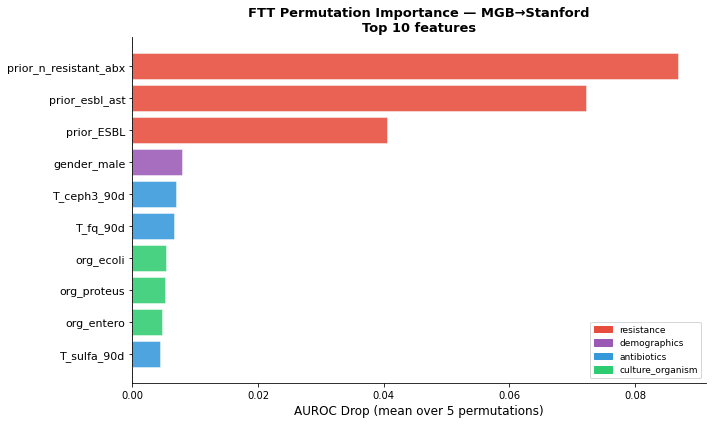

Saved: cross_site_outputs_v10/figures/ftt_importance_m2s.png


In [26]:
# ══════════════════════════════════════════════════════════════
# FTT Permutation Importance — MGB→Stanford
# ══════════════════════════════════════════════════════════════
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feat_to_group = {f: grp for grp, feats in FEATURE_DICT.items() for f in feats}

# Load FTT trained on MGB
ftt_fi_m2s = FTTransformer(N_FEAT, 32, 4, 3, 128, 0.2).to(DEVICE)
ftt_fi_m2s.load_state_dict(ftt_state_mgb)
ftt_fi_m2s.eval()

# Stanford test set (scaled with MGB scaler)
X_te_m2s = splits_m2s["X_tgt_te"]
y_te_m2s = splits_m2s["y_tgt_te"]

with torch.no_grad():
    p_base = torch.sigmoid(ftt_fi_m2s(torch.FloatTensor(X_te_m2s).to(DEVICE))).cpu().numpy()
baseline_m2s = roc_auc_score(y_te_m2s, p_base)
print(f"Baseline MGB→Stanford AUROC: {baseline_m2s:.4f}")

N_REPEATS = 5
rng = np.random.RandomState(SEED)
drops_m2s = []
for fi_idx, feat_name in enumerate(FEATURES):
    d = []
    for _ in range(N_REPEATS):
        X_p = X_te_m2s.copy()
        X_p[:, fi_idx] = rng.permutation(X_p[:, fi_idx])
        with torch.no_grad():
            pp = torch.sigmoid(ftt_fi_m2s(torch.FloatTensor(X_p).to(DEVICE))).cpu().numpy()
        d.append(baseline_m2s - roc_auc_score(y_te_m2s, pp))
    drops_m2s.append(float(np.mean(d)))
    if (fi_idx+1) % 12 == 0: print(f"  {fi_idx+1}/{N_FEAT} done...")

fi_m2s = pd.DataFrame({"feature": FEATURES, "importance": drops_m2s})
fi_m2s = fi_m2s.sort_values("importance", ascending=False).reset_index(drop=True)
fi_m2s["rank"] = fi_m2s.index + 1
fi_m2s["group"] = fi_m2s["feature"].map(feat_to_group)

TOP10_FTT_M2S = fi_m2s.head(10)["feature"].tolist()

print(f"\nFTT Permutation Importance — Top 10 (MGB→Stanford)")
print(f"\n{'Rank':<6} {'Feature':<30} {'Group':<22} {'AUROC Drop':>12}")
print("-"*72)
for _, row in fi_m2s.head(10).iterrows():
    print(f"{int(row['rank']):<6} {row['feature']:<30} {row['group']:<22} {row['importance']:>12.5f}")
print("-"*72)
print(f"\nTop 10: {TOP10_FTT_M2S}")

del ftt_fi_m2s; torch.cuda.empty_cache()

# ── Plot ──────────────────────────────────────────────────────
group_colors = {
    "resistance":          "#e74c3c",
    "antibiotics":         "#3498db",
    "demographics":        "#9b59b6",
    "culture_organism":    "#2ecc71",
    "temporal_interactions":"#f39c12",
    "comorbidities":       "#1abc9c",
    "ward":                "#95a5a6",
    "procedures":          "#e67e22",
}

top10 = fi_m2s.head(10).copy()
colors = [group_colors.get(g, "#bdc3c7") for g in top10["group"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(10), top10["importance"].values[::-1],
               color=colors[::-1], alpha=0.88, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(10))
ax.set_yticklabels(top10["feature"].values[::-1], fontsize=11)
ax.set_xlabel("AUROC Drop (mean over 5 permutations)", fontsize=12)
ax.set_title("FTT Permutation Importance — MGB→Stanford\nTop 10 features",
             fontweight="bold", fontsize=13)

# Legend
from matplotlib.patches import Patch
present_groups = top10["group"].unique()
legend_handles = [Patch(color=group_colors.get(g,"#bdc3c7"), label=g)
                  for g in present_groups]
ax.legend(handles=legend_handles, fontsize=9, loc="lower right")

ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ftt_importance_m2s.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIG_DIR}/ftt_importance_m2s.png")

Baseline Stanford→MGB AUROC: 0.7409
  12/48 done...
  24/48 done...
  36/48 done...
  48/48 done...

FTT Permutation Importance — Top 10 (Stanford→MGB)

Rank   Feature                        Group                    AUROC Drop
------------------------------------------------------------------------
1      prior_ESBL                     resistance                  0.03160
2      has_prior_cx                   temporal_interactions       0.02193
3      prior_n_resistant_abx          resistance                  0.01853
4      T_ceph3_90d                    antibiotics                 0.00942
5      org_entero                     culture_organism            0.00682
6      num_prior_orgs                 resistance                  0.00659
7      gender_male                    demographics                0.00567
8      T_fq_90d                       antibiotics                 0.00492
9      adi_missing                    demographics                0.00472
10     prior_esbl_ast             

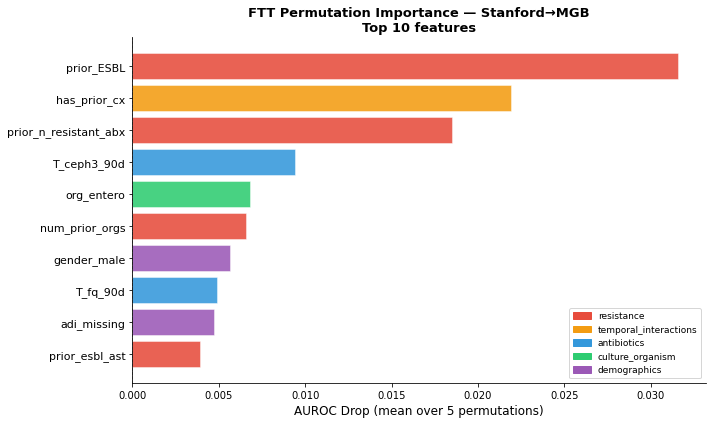

Saved: cross_site_outputs_v10/figures/ftt_importance_s2m.png


In [27]:
# ══════════════════════════════════════════════════════════════
# FTT Permutation Importance — Stanford→MGB
# ══════════════════════════════════════════════════════════════
%matplotlib inline

ftt_fi_s2m = FTTransformer(N_FEAT, 32, 4, 3, 128, 0.2).to(DEVICE)
ftt_fi_s2m.load_state_dict(ftt_state_stan)
ftt_fi_s2m.eval()

# MGB test set (scaled with Stanford scaler)
X_te_s2m = splits_s2m["X_tgt_te"]
y_te_s2m = splits_s2m["y_tgt_te"]

with torch.no_grad():
    p_base2 = torch.sigmoid(ftt_fi_s2m(torch.FloatTensor(X_te_s2m).to(DEVICE))).cpu().numpy()
baseline_s2m = roc_auc_score(y_te_s2m, p_base2)
print(f"Baseline Stanford→MGB AUROC: {baseline_s2m:.4f}")

rng2 = np.random.RandomState(SEED)
drops_s2m = []
for fi_idx, feat_name in enumerate(FEATURES):
    d = []
    for _ in range(N_REPEATS):
        X_p = X_te_s2m.copy()
        X_p[:, fi_idx] = rng2.permutation(X_p[:, fi_idx])
        with torch.no_grad():
            pp = torch.sigmoid(ftt_fi_s2m(torch.FloatTensor(X_p).to(DEVICE))).cpu().numpy()
        d.append(baseline_s2m - roc_auc_score(y_te_s2m, pp))
    drops_s2m.append(float(np.mean(d)))
    if (fi_idx+1) % 12 == 0: print(f"  {fi_idx+1}/{N_FEAT} done...")

fi_s2m = pd.DataFrame({"feature": FEATURES, "importance": drops_s2m})
fi_s2m = fi_s2m.sort_values("importance", ascending=False).reset_index(drop=True)
fi_s2m["rank"] = fi_s2m.index + 1
fi_s2m["group"] = fi_s2m["feature"].map(feat_to_group)

TOP10_FTT_S2M = fi_s2m.head(10)["feature"].tolist()

print(f"\nFTT Permutation Importance — Top 10 (Stanford→MGB)")
print(f"\n{'Rank':<6} {'Feature':<30} {'Group':<22} {'AUROC Drop':>12}")
print("-"*72)
for _, row in fi_s2m.head(10).iterrows():
    print(f"{int(row['rank']):<6} {row['feature']:<30} {row['group']:<22} {row['importance']:>12.5f}")
print("-"*72)
print(f"\nTop 10: {TOP10_FTT_S2M}")

del ftt_fi_s2m; torch.cuda.empty_cache()

# ── Side-by-side comparison ───────────────────────────────────
agreement = set(TOP10_FTT_M2S) & set(TOP10_FTT_S2M)
print(f"\n{'='*60}")
print(f"DIRECTION AGREEMENT")
print(f"  MGB→Stan:  {TOP10_FTT_M2S}")
print(f"  Stan→MGB:  {TOP10_FTT_S2M}")
print(f"  Common ({len(agreement)}/10): {sorted(agreement)}")
print(f"  Only M2S: {sorted(set(TOP10_FTT_M2S)-set(TOP10_FTT_S2M))}")
print(f"  Only S2M: {sorted(set(TOP10_FTT_S2M)-set(TOP10_FTT_M2S))}")
print(f"{'='*60}")

# ── Plot ──────────────────────────────────────────────────────
top10_s = fi_s2m.head(10).copy()
colors_s = [group_colors.get(g, "#bdc3c7") for g in top10_s["group"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(10), top10_s["importance"].values[::-1],
        color=colors_s[::-1], alpha=0.88, edgecolor="white", linewidth=0.5)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_s["feature"].values[::-1], fontsize=11)
ax.set_xlabel("AUROC Drop (mean over 5 permutations)", fontsize=12)
ax.set_title("FTT Permutation Importance — Stanford→MGB\nTop 10 features",
             fontweight="bold", fontsize=13)
present_groups_s = top10_s["group"].unique()
legend_handles_s = [Patch(color=group_colors.get(g,"#bdc3c7"), label=g)
                    for g in present_groups_s]
ax.legend(handles=legend_handles_s, fontsize=9, loc="lower right")
ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.4)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ftt_importance_s2m.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIG_DIR}/ftt_importance_s2m.png")

MGB→Stanford FTT-10 features: ['prior_n_resistant_abx', 'prior_esbl_ast', 'prior_ESBL', 'gender_male', 'T_ceph3_90d', 'T_fq_90d', 'org_ecoli', 'org_proteus', 'org_entero', 'T_sulfa_90d']
Training source FTT-10 on MGB...
    FTT early stop ep 41

Zero-shot MGB→Stanford FTT-10: AUROC=0.6917  AUPRC=0.2530

n_ft          AUROC    AUPRC
------------------------------
0 (zs)       0.6917   0.2530
    FTT early stop ep 26
500          0.7024   0.3009
    FTT early stop ep 20
1,000        0.7087   0.2991
    FTT early stop ep 33
2,000        0.7136   0.3152
    FTT early stop ep 25
5,000        0.7120   0.3177
    FTT early stop ep 17
ALL          0.7174   0.3182


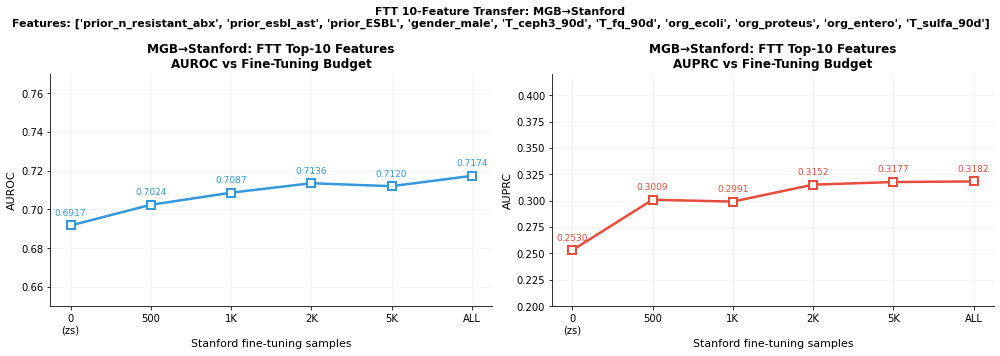

Saved: cross_site_outputs_v10/figures/ftt10_finetune_m2s.png


In [28]:
# ══════════════════════════════════════════════════════════════
# 10-Feat Fine-Tuning — MGB→Stanford
# Uses TOP10_FTT_M2S
# ══════════════════════════════════════════════════════════════
%matplotlib inline

print(f"MGB→Stanford FTT-10 features: {TOP10_FTT_M2S}")
N_M2S = len(TOP10_FTT_M2S)

# Scaler fit on MGB top-10
sc_m2s = StandardScaler()
X_mgb_10 = sc_m2s.fit_transform(mgb[TOP10_FTT_M2S].to_numpy(dtype=np.float32))
X_stan_10 = sc_m2s.transform(stan[TOP10_FTT_M2S].to_numpy(dtype=np.float32))
y_mgb_ = mgb["ESBL"].to_numpy(dtype=np.float32)
y_stan_ = stan["ESBL"].to_numpy(dtype=np.float32)

# Patient-level train/val split on MGB
gss_ = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_i, val_i = next(gss_.split(X_mgb_10, y_mgb_,
                               groups=mgb["patient_id"].astype(str).to_numpy()))
X_tr_, y_tr_ = X_mgb_10[tr_i], y_mgb_[tr_i]
X_val_, y_val_ = X_mgb_10[val_i], y_mgb_[val_i]

cw_ = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr_)
sw_ = np.where(y_tr_==1, cw_[1], cw_[0])
trl_ = DataLoader(TensorDataset(torch.tensor(X_tr_, dtype=torch.float32),
    torch.tensor(y_tr_, dtype=torch.float32)), batch_size=256,
    sampler=WeightedRandomSampler(sw_, len(sw_), replacement=True), drop_last=True)
vll_ = DataLoader(TensorDataset(torch.tensor(X_val_, dtype=torch.float32),
    torch.tensor(y_val_, dtype=torch.float32)), batch_size=2048)

# Train source FTT-10
print("Training source FTT-10 on MGB...")
ftt10_m2s = FTTransformer(N_M2S, 32, 4, 3, 128, 0.2).to(DEVICE)
ftt10_m2s = train_ftt(ftt10_m2s, trl_, vll_, epochs=150, lr=5e-4)
state_m2s_10 = copy.deepcopy(ftt10_m2s.state_dict())

p_zs = pred_ftt(ftt10_m2s, X_stan_10)
auroc_zs_m2s = roc_auc_score(y_stan_, p_zs)
auprc_zs_m2s = average_precision_score(y_stan_, p_zs)
print(f"\nZero-shot MGB→Stanford FTT-10: AUROC={auroc_zs_m2s:.4f}  AUPRC={auprc_zs_m2s:.4f}")
del ftt10_m2s; torch.cuda.empty_cache()

# Fine-tuning splits on Stanford (patient-level)
stan_ids_ = stan["patient_id"].to_numpy()
gss_ft = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
ft_pool_i, ft_held_i = next(gss_ft.split(stan, groups=stan_ids_))
gss_ft2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
v_i, t_i = next(gss_ft2.split(stan.iloc[ft_held_i],
                               groups=stan_ids_[ft_held_i]))
ft_val_i = ft_held_i[v_i]; ft_te_i = ft_held_i[t_i]

X_pool = sc_m2s.transform(stan.iloc[ft_pool_i][TOP10_FTT_M2S].to_numpy(dtype=np.float32))
X_fval = sc_m2s.transform(stan.iloc[ft_val_i][TOP10_FTT_M2S].to_numpy(dtype=np.float32))
X_fte  = sc_m2s.transform(stan.iloc[ft_te_i][TOP10_FTT_M2S].to_numpy(dtype=np.float32))
y_pool = stan.iloc[ft_pool_i]["ESBL"].to_numpy(dtype=np.float32)
y_fval = stan.iloc[ft_val_i]["ESBL"].to_numpy(dtype=np.float32)
y_fte  = stan.iloc[ft_te_i]["ESBL"].to_numpy(dtype=np.float32)

budgets_m2s = [0, 500, 1000, 2000, 5000, len(X_pool)]
aurocs_m2s  = [auroc_zs_m2s]
auprcs_m2s  = [auprc_zs_m2s]

print(f"\n{'n_ft':<10} {'AUROC':>8} {'AUPRC':>8}")
print("-"*30)
print(f"{'0 (zs)':<10} {auroc_zs_m2s:>8.4f} {auprc_zs_m2s:>8.4f}")

for n in budgets_m2s[1:]:
    n = min(n, len(X_pool))
    rng_ = np.random.RandomState(SEED)
    pi = np.where(y_pool==1)[0]; ni = np.where(y_pool==0)[0]
    np_ = max(1, int(n * y_pool.mean()))
    sub = np.concatenate([rng_.choice(pi, min(np_, len(pi)), replace=False),
                          rng_.choice(ni, min(n-np_, len(ni)), replace=False)])
    Xs, ys = X_pool[sub], y_pool[sub]

    cws = compute_class_weight("balanced", classes=np.array([0,1]), y=ys)
    sws = np.where(ys==1, cws[1], cws[0])
    trl_ft = DataLoader(TensorDataset(torch.tensor(Xs, dtype=torch.float32),
        torch.tensor(ys, dtype=torch.float32)),
        batch_size=min(256, max(len(Xs)//4, 16)),
        sampler=WeightedRandomSampler(sws, len(sws), replacement=True), drop_last=True)
    vll_ft = DataLoader(TensorDataset(torch.tensor(X_fval, dtype=torch.float32),
        torch.tensor(y_fval, dtype=torch.float32)), batch_size=2048)

    m = FTTransformer(N_M2S, 32, 4, 3, 128, 0.2).to(DEVICE)
    m.load_state_dict(state_m2s_10)
    m = train_ftt(m, trl_ft, vll_ft, epochs=60, lr=1e-4, pat=10)
    p = pred_ftt(m, X_fte)
    ar = roc_auc_score(y_fte, p); ap = average_precision_score(y_fte, p)
    aurocs_m2s.append(ar); auprcs_m2s.append(ap)
    lbl = f"{n:,}" if n < len(X_pool) else "ALL"
    print(f"{lbl:<10} {ar:>8.4f} {ap:>8.4f}")
    del m; torch.cuda.empty_cache()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

x_labels = ["0\n(zs)", "500", "1K", "2K", "5K", "ALL"]

axes[0].plot(range(len(budgets_m2s)), aurocs_m2s, "s-", color="#3498db",
             lw=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
for i, (x, y) in enumerate(zip(range(len(budgets_m2s)), aurocs_m2s)):
    axes[0].annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, color="#3498db")
axes[0].set_xticks(range(len(budgets_m2s)))
axes[0].set_xticklabels(x_labels, fontsize=10)
axes[0].set_xlabel("Stanford fine-tuning samples", fontsize=11)
axes[0].set_ylabel("AUROC", fontsize=11)
axes[0].set_title("MGB→Stanford: FTT Top-10 Features\nAUROC vs Fine-Tuning Budget",
                  fontweight="bold")
axes[0].set_ylim(0.65, 0.77)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.15)

axes[1].plot(range(len(budgets_m2s)), auprcs_m2s, "s-", color="#e74c3c",
             lw=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
for i, (x, y) in enumerate(zip(range(len(budgets_m2s)), auprcs_m2s)):
    axes[1].annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, color="#e74c3c")
axes[1].set_xticks(range(len(budgets_m2s)))
axes[1].set_xticklabels(x_labels, fontsize=10)
axes[1].set_xlabel("Stanford fine-tuning samples", fontsize=11)
axes[1].set_ylabel("AUPRC", fontsize=11)
axes[1].set_title("MGB→Stanford: FTT Top-10 Features\nAUPRC vs Fine-Tuning Budget",
                  fontweight="bold")
axes[1].set_ylim(0.20, 0.42)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
axes[1].set_facecolor("white"); axes[1].grid(alpha=0.15)

plt.suptitle(f"FTT 10-Feature Transfer: MGB→Stanford\nFeatures: {TOP10_FTT_M2S}",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ftt10_finetune_m2s.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIG_DIR}/ftt10_finetune_m2s.png")

Stanford→MGB FTT-10 features: ['prior_ESBL', 'has_prior_cx', 'prior_n_resistant_abx', 'T_ceph3_90d', 'org_entero', 'num_prior_orgs', 'gender_male', 'T_fq_90d', 'adi_missing', 'prior_esbl_ast']
Training source FTT-10 on Stanford...
    FTT early stop ep 31

Zero-shot Stanford→MGB FTT-10: AUROC=0.7277  AUPRC=0.4130

n_ft          AUROC    AUPRC
------------------------------
0 (zs)       0.7277   0.4130
    FTT early stop ep 29
500          0.7663   0.4464
    FTT early stop ep 37
1,000        0.7731   0.4549
    FTT early stop ep 46
2,000        0.7795   0.4688
    FTT early stop ep 44
5,000        0.7810   0.4717
    FTT early stop ep 50
ALL          0.7850   0.4743


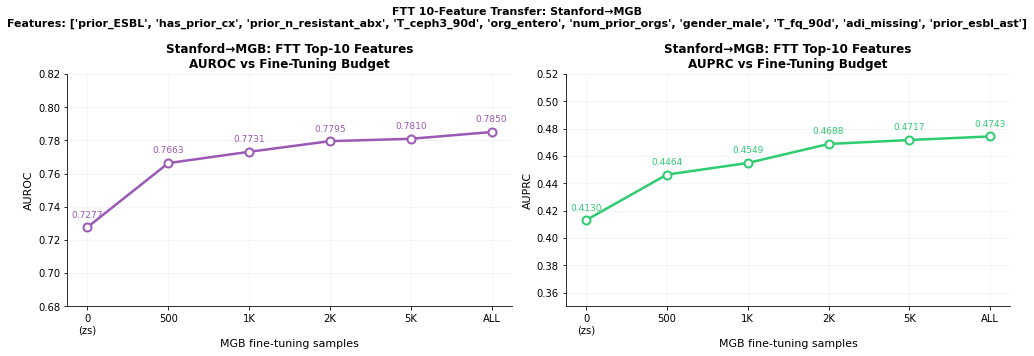

Saved: cross_site_outputs_v10/figures/ftt10_finetune_s2m.png


In [29]:
# ══════════════════════════════════════════════════════════════
# 10-Feat Fine-Tuning — Stanford→MGB
# Uses TOP10_FTT_S2M 
# ══════════════════════════════════════════════════════════════
%matplotlib inline

print(f"Stanford→MGB FTT-10 features: {TOP10_FTT_S2M}")
N_S2M = len(TOP10_FTT_S2M)

# Scaler fit on Stanford top-10
sc_s2m = StandardScaler()
X_stan_10s = sc_s2m.fit_transform(stan[TOP10_FTT_S2M].to_numpy(dtype=np.float32))
X_mgb_10s  = sc_s2m.transform(mgb[TOP10_FTT_S2M].to_numpy(dtype=np.float32))

# Patient-level train/val split on Stanford
gss_s = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
tr_is, val_is = next(gss_s.split(X_stan_10s, y_stan_,
                                  groups=stan["patient_id"].astype(str).to_numpy()))
X_tr_s, y_tr_s   = X_stan_10s[tr_is], y_stan_[tr_is]
X_val_s, y_val_s = X_stan_10s[val_is], y_stan_[val_is]

cw_s = compute_class_weight("balanced", classes=np.array([0,1]), y=y_tr_s)
sw_s = np.where(y_tr_s==1, cw_s[1], cw_s[0])
trl_s = DataLoader(TensorDataset(torch.tensor(X_tr_s, dtype=torch.float32),
    torch.tensor(y_tr_s, dtype=torch.float32)), batch_size=256,
    sampler=WeightedRandomSampler(sw_s, len(sw_s), replacement=True), drop_last=True)
vll_s = DataLoader(TensorDataset(torch.tensor(X_val_s, dtype=torch.float32),
    torch.tensor(y_val_s, dtype=torch.float32)), batch_size=2048)

print("Training source FTT-10 on Stanford...")
ftt10_s2m = FTTransformer(N_S2M, 32, 4, 3, 128, 0.2).to(DEVICE)
ftt10_s2m = train_ftt(ftt10_s2m, trl_s, vll_s, epochs=150, lr=5e-4)
state_s2m_10 = copy.deepcopy(ftt10_s2m.state_dict())

p_zs_s = pred_ftt(ftt10_s2m, X_mgb_10s)
auroc_zs_s2m = roc_auc_score(y_mgb_, p_zs_s)
auprc_zs_s2m = average_precision_score(y_mgb_, p_zs_s)
print(f"\nZero-shot Stanford→MGB FTT-10: AUROC={auroc_zs_s2m:.4f}  AUPRC={auprc_zs_s2m:.4f}")
del ftt10_s2m; torch.cuda.empty_cache()

# Fine-tuning splits on MGB (patient-level)
mgb_ids_ = mgb["patient_id"].to_numpy()
gss_fm = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
fm_pool_i, fm_held_i = next(gss_fm.split(mgb, groups=mgb_ids_))
gss_fm2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=SEED)
mv_i, mt_i = next(gss_fm2.split(mgb.iloc[fm_held_i], groups=mgb_ids_[fm_held_i]))
fm_val_i = fm_held_i[mv_i]; fm_te_i = fm_held_i[mt_i]

X_mpool = sc_s2m.transform(mgb.iloc[fm_pool_i][TOP10_FTT_S2M].to_numpy(dtype=np.float32))
X_mfval = sc_s2m.transform(mgb.iloc[fm_val_i][TOP10_FTT_S2M].to_numpy(dtype=np.float32))
X_mfte  = sc_s2m.transform(mgb.iloc[fm_te_i][TOP10_FTT_S2M].to_numpy(dtype=np.float32))
y_mpool = mgb.iloc[fm_pool_i]["ESBL"].to_numpy(dtype=np.float32)
y_mfval = mgb.iloc[fm_val_i]["ESBL"].to_numpy(dtype=np.float32)
y_mfte  = mgb.iloc[fm_te_i]["ESBL"].to_numpy(dtype=np.float32)

budgets_s2m = [0, 500, 1000, 2000, 5000, len(X_mpool)]
aurocs_s2m  = [auroc_zs_s2m]
auprcs_s2m  = [auprc_zs_s2m]

print(f"\n{'n_ft':<10} {'AUROC':>8} {'AUPRC':>8}")
print("-"*30)
print(f"{'0 (zs)':<10} {auroc_zs_s2m:>8.4f} {auprc_zs_s2m:>8.4f}")

for n in budgets_s2m[1:]:
    n = min(n, len(X_mpool))
    rng_m = np.random.RandomState(SEED)
    pim = np.where(y_mpool==1)[0]; nim = np.where(y_mpool==0)[0]
    npm = max(1, int(n * y_mpool.mean()))
    subm = np.concatenate([rng_m.choice(pim, min(npm, len(pim)), replace=False),
                           rng_m.choice(nim, min(n-npm, len(nim)), replace=False)])
    Xsm, ysm = X_mpool[subm], y_mpool[subm]

    cwsm = compute_class_weight("balanced", classes=np.array([0,1]), y=ysm)
    swsm = np.where(ysm==1, cwsm[1], cwsm[0])
    trl_fm = DataLoader(TensorDataset(torch.tensor(Xsm, dtype=torch.float32),
        torch.tensor(ysm, dtype=torch.float32)),
        batch_size=min(256, max(len(Xsm)//4, 16)),
        sampler=WeightedRandomSampler(swsm, len(swsm), replacement=True), drop_last=True)
    vll_fm = DataLoader(TensorDataset(torch.tensor(X_mfval, dtype=torch.float32),
        torch.tensor(y_mfval, dtype=torch.float32)), batch_size=2048)

    mm = FTTransformer(N_S2M, 32, 4, 3, 128, 0.2).to(DEVICE)
    mm.load_state_dict(state_s2m_10)
    mm = train_ftt(mm, trl_fm, vll_fm, epochs=60, lr=1e-4, pat=10)
    pm = pred_ftt(mm, X_mfte)
    arm = roc_auc_score(y_mfte, pm); apm = average_precision_score(y_mfte, pm)
    aurocs_s2m.append(arm); auprcs_s2m.append(apm)
    lblm = f"{n:,}" if n < len(X_mpool) else "ALL"
    print(f"{lblm:<10} {arm:>8.4f} {apm:>8.4f}")
    del mm; torch.cuda.empty_cache()

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

x_labels_s = ["0\n(zs)", "500", "1K", "2K", "5K", "ALL"]

axes[0].plot(range(len(budgets_s2m)), aurocs_s2m, "o-", color="#9b59b6",
             lw=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
for i, (x, y) in enumerate(zip(range(len(budgets_s2m)), aurocs_s2m)):
    axes[0].annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, color="#9b59b6")
axes[0].set_xticks(range(len(budgets_s2m)))
axes[0].set_xticklabels(x_labels_s, fontsize=10)
axes[0].set_xlabel("MGB fine-tuning samples", fontsize=11)
axes[0].set_ylabel("AUROC", fontsize=11)
axes[0].set_title("Stanford→MGB: FTT Top-10 Features\nAUROC vs Fine-Tuning Budget",
                  fontweight="bold")
axes[0].set_ylim(0.68, 0.82)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)
axes[0].set_facecolor("white"); axes[0].grid(alpha=0.15)

axes[1].plot(range(len(budgets_s2m)), auprcs_s2m, "o-", color="#2ecc71",
             lw=2.5, markersize=8, markerfacecolor="white", markeredgewidth=2)
for i, (x, y) in enumerate(zip(range(len(budgets_s2m)), auprcs_s2m)):
    axes[1].annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, color="#2ecc71")
axes[1].set_xticks(range(len(budgets_s2m)))
axes[1].set_xticklabels(x_labels_s, fontsize=10)
axes[1].set_xlabel("MGB fine-tuning samples", fontsize=11)
axes[1].set_ylabel("AUPRC", fontsize=11)
axes[1].set_title("Stanford→MGB: FTT Top-10 Features\nAUPRC vs Fine-Tuning Budget",
                  fontweight="bold")
axes[1].set_ylim(0.35, 0.52)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
axes[1].set_facecolor("white"); axes[1].grid(alpha=0.15)

plt.suptitle(f"FTT 10-Feature Transfer: Stanford→MGB\nFeatures: {TOP10_FTT_S2M}",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ftt10_finetune_s2m.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIG_DIR}/ftt10_finetune_s2m.png")

In [21]:
# ══════════════════════════════════════════════════════════════
# SUBGROUP ANALYSIS — FTT 48 features, both directions
# ══════════════════════════════════════════════════════════════

# Reload FTT states trained on full data
ft_mgb = FTTransformer(N_FEAT, 32, 4, 3, 128, 0.2).to(DEVICE)
ft_mgb.load_state_dict(ftt_state_mgb)

ft_stan = FTTransformer(N_FEAT, 32, 4, 3, 128, 0.2).to(DEVICE)
ft_stan.load_state_dict(ftt_state_stan)

# Scaled test arrays
X_stan_sc = scaler_mgb.transform(stan[FEATURES].to_numpy(dtype=np.float32))
X_mgb_sc  = scaler_stan.transform(mgb[FEATURES].to_numpy(dtype=np.float32))

stan["p_m2s"] = pred_ftt(ft_mgb, X_stan_sc)
mgb["p_s2m"]  = pred_ftt(ft_stan, X_mgb_sc)

del ft_mgb, ft_stan; torch.cuda.empty_cache()

def subgroup_auroc(df, pred_col, label):
    y = df["ESBL"].to_numpy()
    p = df[pred_col].to_numpy()
    if y.sum() < 5 or (1-y).sum() < 5:
        return None
    return {
        "subgroup": label,
        "n": len(df),
        "n_pos": int(y.sum()),
        "auroc": round(roc_auc_score(y, p), 4),
        "auprc": round(average_precision_score(y, p), 4),
    }

AGE_BINS = {
    "18-34": [1, 2],
    "35-54": [3, 4],
    "55-64": [5],
    "65-74": [6],
    ">=75":  [7, 8, 9],
}

rows = []

# ── MGB→Stanford direction: predict on stan ──────────────────
for label, codes in AGE_BINS.items():
    sub = stan[stan["age_encoded"].isin(codes)]
    r = subgroup_auroc(sub, "p_m2s", f"Age {label}")
    if r: rows.append({**r, "direction": "MGB→Stanford"})

for sex, val in [("Male", 1), ("Female", 0)]:
    sub = stan[stan["gender_male"] == val]
    r = subgroup_auroc(sub, "p_m2s", sex)
    if r: rows.append({**r, "direction": "MGB→Stanford"})

adi_bins = [("ADI low (0-33)", stan["adi_score_clean"].between(0,33) & (stan["adi_missing"]==0)),
            ("ADI mid (34-66)", stan["adi_score_clean"].between(34,66) & (stan["adi_missing"]==0)),
            ("ADI high (67-100)", stan["adi_score_clean"].between(67,100) & (stan["adi_missing"]==0)),
            ("ADI missing", stan["adi_missing"]==1)]
for label, mask in adi_bins:
    r = subgroup_auroc(stan[mask], "p_m2s", label)
    if r: rows.append({**r, "direction": "MGB→Stanford"})

for label, val in [("Prior ESBL+", 1), ("No prior ESBL", 0)]:
    sub = stan[stan["prior_ESBL"] == val]
    r = subgroup_auroc(sub, "p_m2s", label)
    if r: rows.append({**r, "direction": "MGB→Stanford"})

# ── Stanford→MGB direction: predict on mgb ──────────────────
for label, codes in AGE_BINS.items():
    sub = mgb[mgb["age_encoded"].isin(codes)]
    r = subgroup_auroc(sub, "p_s2m", f"Age {label}")
    if r: rows.append({**r, "direction": "Stanford→MGB"})

for sex, val in [("Male", 1), ("Female", 0)]:
    sub = mgb[mgb["gender_male"] == val]
    r = subgroup_auroc(sub, "p_s2m", sex)
    if r: rows.append({**r, "direction": "Stanford→MGB"})

adi_bins_m = [("ADI low (0-33)", mgb["adi_score_clean"].between(0,33) & (mgb["adi_missing"]==0)),
              ("ADI mid (34-66)", mgb["adi_score_clean"].between(34,66) & (mgb["adi_missing"]==0)),
              ("ADI high (67-100)", mgb["adi_score_clean"].between(67,100) & (mgb["adi_missing"]==0)),
              ("ADI missing", mgb["adi_missing"]==1)]
for label, mask in adi_bins_m:
    r = subgroup_auroc(mgb[mask], "p_s2m", label)
    if r: rows.append({**r, "direction": "Stanford→MGB"})

for label, val in [("Prior ESBL+", 1), ("No prior ESBL", 0)]:
    sub = mgb[mgb["prior_ESBL"] == val]
    r = subgroup_auroc(sub, "p_s2m", label)
    if r: rows.append({**r, "direction": "Stanford→MGB"})

sg_df = pd.DataFrame(rows)
print("\nSUBGROUP ANALYSIS (FTT, 48 features)")
print("="*70)
for direction in ["MGB→Stanford", "Stanford→MGB"]:
    print(f"\n{direction}:")
    print(f"  {'Subgroup':<25} {'n':>8} {'ESBL+':>6} {'AUROC':>7} {'AUPRC':>7}")
    print(f"  {'-'*55}")
    sub = sg_df[sg_df["direction"]==direction]
    for _, row in sub.iterrows():
        print(f"  {row['subgroup']:<25} {row['n']:>8,} {row['n_pos']:>6,} {row['auroc']:>7.4f} {row['auprc']:>7.4f}")


SUBGROUP ANALYSIS (FTT, 48 features)

MGB→Stanford:
  Subgroup                         n  ESBL+   AUROC   AUPRC
  -------------------------------------------------------
  Age 18-34                   15,102    960  0.6637  0.1933
  Age 35-54                   16,402  1,544  0.6930  0.2912
  Age 55-64                   11,740  1,361  0.7138  0.3259
  Age 65-74                   14,931  1,856  0.7076  0.3337
  Age >=75                    25,198  2,977  0.6996  0.3104
  Male                        15,646  2,550  0.7081  0.4065
  Female                      67,727  6,148  0.6840  0.2513
  ADI low (0-33)              63,609  6,753  0.7075  0.3137
  ADI mid (34-66)              2,680    396  0.6926  0.3382
  ADI high (67-100)              359     64  0.8059  0.5852
  ADI missing                 16,725  1,485  0.6827  0.2347
  Prior ESBL+                  6,609  2,637  0.6740  0.5983
  No prior ESBL               76,764  6,061  0.6296  0.1431

Stanford→MGB:
  Subgroup                        

In [22]:
# ══════════════════════════════════════════════════════════════
# CLINICAL OPERATING POINT — 90% sensitivity
# ══════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix

print("\n\nCLINICAL OPERATING POINT (FTT, 90% sensitivity)")
print("="*60)
for direction, y_true, p_pred, prev in [
    ("MGB→Stanford", stan["ESBL"].to_numpy(), stan["p_m2s"].to_numpy(), stan["ESBL"].mean()),
    ("Stanford→MGB", mgb["ESBL"].to_numpy(),  mgb["p_s2m"].to_numpy(),  mgb["ESBL"].mean()),
]:
    fpr, tpr, thresholds = roc_curve(y_true, p_pred)
    # Find threshold closest to 90% sensitivity
    idx = np.argmin(np.abs(tpr - 0.90))
    thresh = thresholds[idx]
    sens = tpr[idx]
    spec = 1 - fpr[idx]
    preds = (p_pred >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    print(f"\n  {direction} (prevalence {prev:.1%}):")
    print(f"    Threshold={thresh:.3f}  Sensitivity={sens:.1%}  Specificity={spec:.1%}")
    print(f"    PPV={ppv:.1%}  NPV={npv:.1%}")
    print(f"    TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}")




CLINICAL OPERATING POINT (FTT, 90% sensitivity)

  MGB→Stanford (prevalence 10.4%):
    Threshold=0.293  Sensitivity=90.0%  Specificity=22.1%
    PPV=11.9%  NPV=95.0%
    TP=7,828  FP=58,199  FN=870  TN=16,476

  Stanford→MGB (prevalence 14.4%):
    Threshold=0.318  Sensitivity=90.0%  Specificity=27.1%
    PPV=17.2%  NPV=94.1%
    TP=17,301  FP=83,009  FN=1,922  TN=30,852


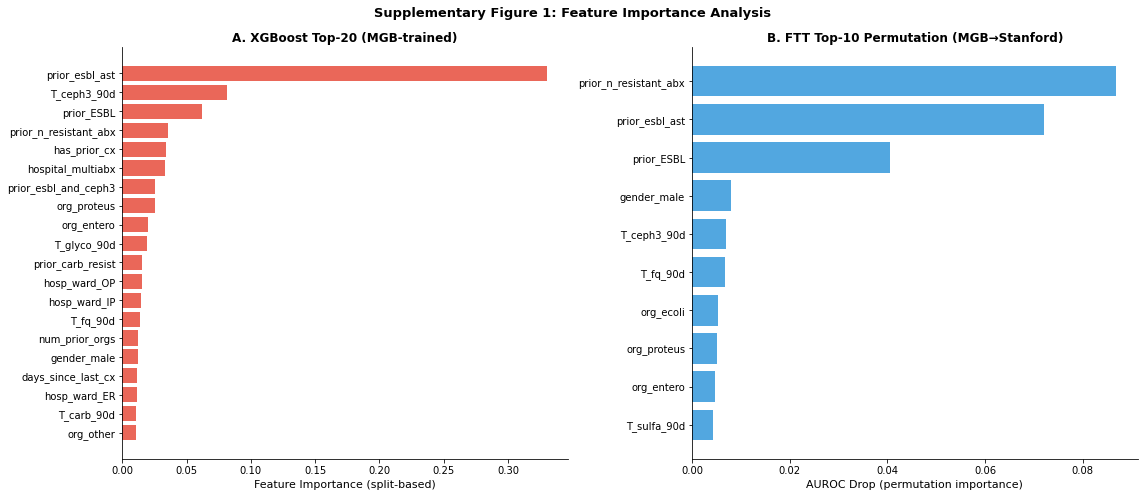

In [31]:

# ══════════════════════════════════════════════════════════════
# SUPP FIGURE 1 — Feature importance
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")

importances = pd.Series(xgb_mgb.feature_importances_, index=FEATURES).sort_values(ascending=False).head(20)
axes[0].barh(importances.index[::-1], importances.values[::-1], color="#e74c3c", alpha=0.85)
axes[0].set_xlabel("Feature Importance (split-based)", fontsize=11)
axes[0].set_title("A. XGBoost Top-20 (MGB-trained)", fontweight="bold", fontsize=12)
axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)
axes[0].set_facecolor("white")

top10_ftt = fi_m2s.head(10).sort_values("importance", ascending=True)
axes[1].barh(top10_ftt["feature"], top10_ftt["importance"], color="#3498db", alpha=0.85)
axes[1].set_xlabel("AUROC Drop (permutation importance)", fontsize=11)
axes[1].set_title("B. FTT Top-10 Permutation (MGB→Stanford)", fontweight="bold", fontsize=12)
axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
axes[1].set_facecolor("white")

plt.suptitle("Supplementary Figure 1: Feature Importance Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/supp_fig1_feature_importance.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

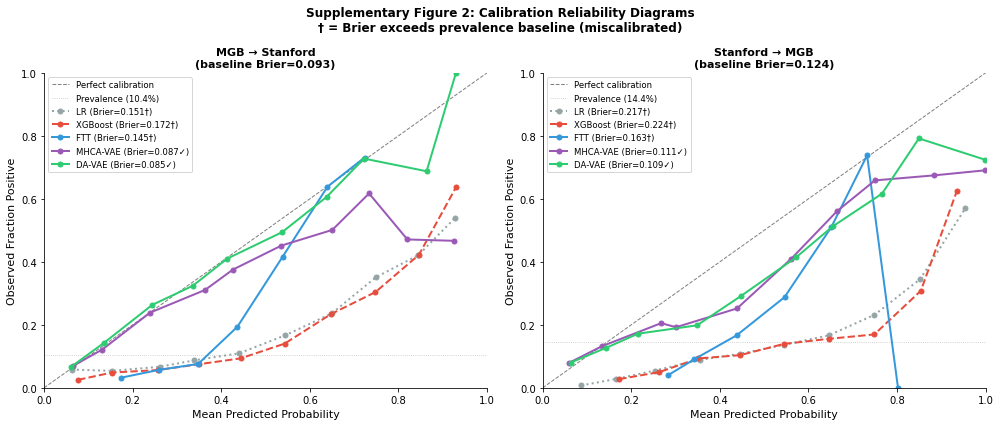

In [32]:

# ══════════════════════════════════════════════════════════════
# SUPP FIGURE 2 — Calibration reliability diagrams
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("white")

for ax, direction, y_true, model_preds, prevalence in [
    (axes[0], "MGB → Stanford", stan["ESBL"].to_numpy(),
     [("LR", res_m2s["LR"]["p"], "#95a5a6", ":"),
      ("XGBoost", res_m2s["XGB"]["p"], "#e74c3c", "--"),
      ("FTT", res_m2s["FTT"]["p"], "#3498db", "-"),
      ("MHCA-VAE", res_m2s["MHCA-VAE"]["p"], "#9b59b6", "-"),
      ("DA-VAE", res_m2s["DA-VAE"]["p"], "#2ecc71", "-")],
     stan["ESBL"].mean()),
    (axes[1], "Stanford → MGB", mgb["ESBL"].to_numpy(),
     [("LR", res_s2m["LR"]["p"], "#95a5a6", ":"),
      ("XGBoost", res_s2m["XGB"]["p"], "#e74c3c", "--"),
      ("FTT", res_s2m["FTT"]["p"], "#3498db", "-"),
      ("MHCA-VAE", res_s2m["MHCA-VAE"]["p"], "#9b59b6", "-"),
      ("DA-VAE", res_s2m["DA-VAE"]["p"], "#2ecc71", "-")],
     mgb["ESBL"].mean()),
]:
    baseline_brier = round(prevalence * (1 - prevalence), 3)
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Perfect calibration")
    ax.axhline(prevalence, color="gray", lw=0.8, ls=":", alpha=0.5,
               label=f"Prevalence ({prevalence:.1%})")
    for name, p, color, ls in model_preds:
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10)
        brier = brier_score_loss(y_true, p)
        flag = "†" if brier > baseline_brier else "✓"
        ax.plot(mean_pred, frac_pos, "o-", color=color, linestyle=ls,
                lw=2, markersize=5, label=f"{name} (Brier={brier:.3f}{flag})")
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax.set_ylabel("Observed Fraction Positive", fontsize=11)
    ax.set_title(f"{direction}\n(baseline Brier={baseline_brier:.3f})", fontweight="bold", fontsize=11)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_facecolor("white")

plt.suptitle("Supplementary Figure 2: Calibration Reliability Diagrams\n† = Brier exceeds prevalence baseline (miscalibrated)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/supp_fig2_calibration.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()

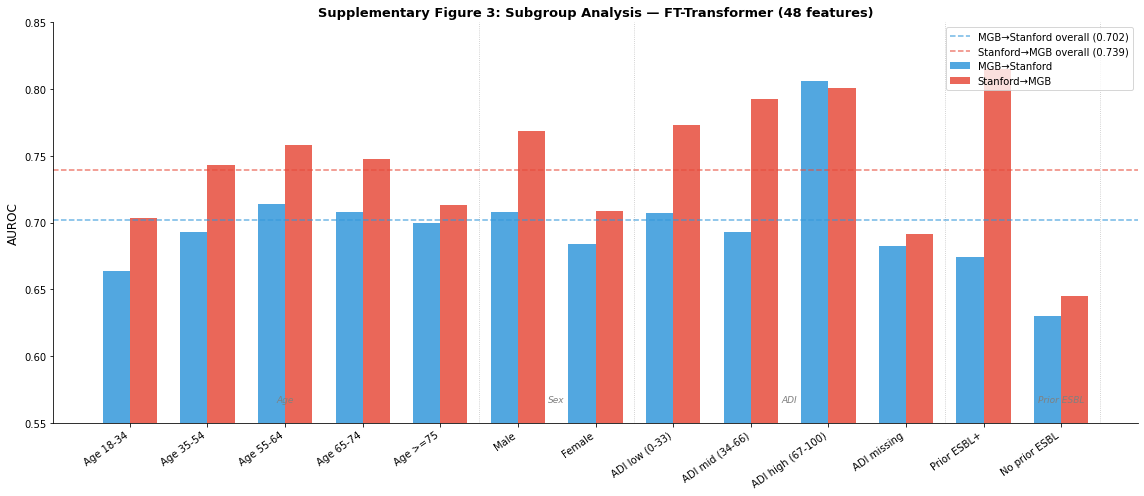

In [33]:
# ══════════════════════════════════════════════════════════════
# SUPP FIGURE 3 — Subgroup AUROC bar chart
# ══════════════════════════════════════════════════════════════
sg_m2s = sg_df[sg_df["direction"]=="MGB→Stanford"].set_index("subgroup")["auroc"]
sg_s2m = sg_df[sg_df["direction"]=="Stanford→MGB"].set_index("subgroup")["auroc"]

ordered = ["Age 18-34","Age 35-54","Age 55-64","Age 65-74","Age >=75",
           "Male","Female",
           "ADI low (0-33)","ADI mid (34-66)","ADI high (67-100)","ADI missing",
           "Prior ESBL+","No prior ESBL"]

vals_ms = [sg_m2s.get(s, np.nan) for s in ordered]
vals_sm = [sg_s2m.get(s, np.nan) for s in ordered]
x = np.arange(len(ordered)); w = 0.35

fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.bar(x - w/2, vals_ms, w, label="MGB→Stanford", color="#3498db", alpha=0.85)
ax.bar(x + w/2, vals_sm, w, label="Stanford→MGB", color="#e74c3c", alpha=0.85)

overall_m2s = res_m2s["FTT"]["auroc"]
overall_s2m = res_s2m["FTT"]["auroc"]
ax.axhline(overall_m2s, color="#3498db", lw=1.5, ls="--", alpha=0.7,
           label=f"MGB→Stanford overall ({overall_m2s:.3f})")
ax.axhline(overall_s2m, color="#e74c3c", lw=1.5, ls="--", alpha=0.7,
           label=f"Stanford→MGB overall ({overall_s2m:.3f})")

ax.set_xticks(x)
ax.set_xticklabels(ordered, rotation=35, ha="right", fontsize=10)
ax.set_ylabel("AUROC", fontsize=12); ax.set_ylim(0.55, 0.85)
ax.set_title("Supplementary Figure 3: Subgroup Analysis — FT-Transformer (48 features)",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10, loc="upper right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

for xpos in [4.5, 6.5, 10.5, 12.5]:
    ax.axvline(xpos, color="gray", lw=0.8, ls=":", alpha=0.5)
for xpos, label in [(2, "Age"), (5.5, "Sex"), (8.5, "ADI"), (12, "Prior ESBL")]:
    ax.text(xpos, 0.565, label, ha="center", fontsize=9, color="gray", style="italic")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/supp_fig3_subgroups.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close()